In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130, 'font.family': 'DejaVu Sans',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 12, 'axes.titleweight': 'bold',
    'axes.labelsize': 10, 'xtick.labelsize': 8.5, 'ytick.labelsize': 8.5,
    'legend.fontsize': 8.5, 'figure.facecolor': 'white',
    'axes.facecolor': '#f8f8f6', 'axes.grid': True,
    'grid.color': 'white', 'grid.linewidth': 0.8,
})

## 1 — Load & Parse Data: bjcta dataset

In [2]:
from pathlib import Path


CSV_PATH = Path("/scratch/umni5/a/li5125/DOE_analysis/RFI-Rider_flexibility_index-/bjcta_para.csv")
df_raw = pd.read_csv(CSV_PATH)

status_clean = df_raw['Trip Status'].astype('string').str.strip().str.lower()
trip_dates = pd.to_datetime(df_raw['Trip Date'], errors='coerce')
purpose_types = sorted(df_raw['Purpose'].dropna().astype(str).unique())

completed_trips = status_clean.isin(['comp', 'completed']).sum()
cancelled_trips = status_clean.isin(['cancel', 'canceled', 'cancelled']).sum()
noshow_trips = status_clean.isin(['noshow', 'no show', 'no-show']).sum()

print(f"Total trips: {len(df_raw):,}")
print(f"Completed trips: {completed_trips:,}")
print(f"Cancelled trips: {cancelled_trips:,}")
print(f"No-show trips: {noshow_trips:,}")
print(f"Unique customers: {df_raw['Customer Number'].nunique():,}")
print(f"Purpose types ({len(purpose_types)}): {purpose_types}")
print(f"Trip date range: {trip_dates.min().date()} to {trip_dates.max().date()}")
print(f"Columns:  {list(df_raw.columns)}")
df_raw.head(3)

Total trips: 165,891
Completed trips: 91,414
Cancelled trips: 63,968
No-show trips: 10,509
Unique customers: 1,432
Purpose types (6): ['Dialysis', 'General', 'Medical', 'Other', 'School', 'Work']
Trip date range: 2022-06-01 to 2023-02-28
Columns:  ['Customer Number', 'Trip ID', 'Trip Date', 'Trip Status', 'Cancel Agent', 'Cancel Time', 'Cancel Type', 'Earliest Pick-up', 'Latest Drop-off Time', 'Requested Drop-off Time', 'Run ID', 'Latest Pick-up Time', 'Scheduled Pick-up Arrival Time', 'Pick-up Street', 'Pick-up Street Number', 'Pick-up Zipcode', 'Drop-off Street', 'Drop-off Street Number', 'Drop-off Zipcode', 'Purpose', 'pickup_address', 'dropoff_address', 'pickup_lat', 'pickup_lon', 'dropoff_lat', 'dropoff_lon', 'idx']


,Customer Number,Trip ID,Trip Date,Trip Status,Cancel Agent,Cancel Time,Cancel Type,Earliest Pick-up,Latest Drop-off Time,Requested Drop-off Time,...,Drop-off Street Number,Drop-off Zipcode,Purpose,pickup_address,dropoff_address,pickup_lat,pickup_lon,dropoff_lat,dropoff_lon,idx
0,5294,350962,6/1/22,comp,NaN,NaN,NaN,4:11,4:55,5:00,...,3201,35222.0,Dialysis,"3110 44th Ave N, 35207","3201 3rd Ave S, 35222",33.568256,-86.806758,33.517799,-86.786011,0
1,3321,346579,6/1/22,comp,NaN,NaN,NaN,4:12,4:55,5:00,...,728,35233.0,Dialysis,"6905 65th St S, 35212","728 Richard Arrington Jr Blvd S, 35233",33.542780,-86.731495,33.506276,-86.798409,1
2,5906,350156,6/1/22,comp,NaN,NaN,NaN,4:16,4:55,5:00,...,3201,35222.0,Dialysis,"204 59th St S, 35212","3201 3rd Ave S, 35222",33.541387,-86.747910,33.517799,-86.786011,2


# Here, we discuss the completion rate for each purpose, and we also summarize the cancellation types. 

In [3]:
purpose_completion_rate = (
    df_raw.assign(status_clean=status_clean)
    .dropna(subset=['Purpose'])
    .groupby('Purpose')
    .agg(
        total_trips=('Trip ID', 'count'),
        completed_trips=('status_clean', lambda s: s.isin(['comp', 'completed']).sum()),
        cancelled_trips=('status_clean', lambda s: s.isin(['cancel', 'canceled', 'cancelled']).sum()),
        noshow_trips=('status_clean', lambda s: s.isin(['noshow', 'no show', 'no-show']).sum()),
    )
)

purpose_completion_rate['completed_rate'] = (
    purpose_completion_rate['completed_trips'] / purpose_completion_rate['total_trips']
)
purpose_completion_rate = purpose_completion_rate.sort_values('completed_rate', ascending=False)

display(purpose_completion_rate.style.format({
    'total_trips': '{:,.0f}',
    'completed_trips': '{:,.0f}',
    'cancelled_trips': '{:,.0f}',
    'noshow_trips': '{:,.0f}',
    'completed_rate': '{:.2%}',
}))

cancel_statuses = ['cancel', 'canceled', 'cancelled']
cancelled_mask = status_clean.isin(cancel_statuses)
df_cancelled = df_raw.loc[cancelled_mask].copy()
df_cancelled['cancel_type_clean'] = (
    df_cancelled['Cancel Type']
    .fillna('Missing / Unknown')
    .astype(str)
    .str.strip()
    .replace('', 'Missing / Unknown')
)

total_cancellations = int(cancelled_mask.sum())
cancel_type_summary = (
    df_cancelled
    .groupby('cancel_type_clean')
    .agg(num_cancellations=('Trip ID', 'count'))
    .sort_values('num_cancellations', ascending=False)
)
cancel_type_summary['share_of_cancellations'] = (
    cancel_type_summary['num_cancellations'] / total_cancellations
)

print(f"Total cancellations: {total_cancellations:,}")
print(f"Cancellation types: {cancel_type_summary.shape[0]:,}")
display(cancel_type_summary.style.format({
    'num_cancellations': '{:,.0f}',
    'share_of_cancellations': '{:.2%}',
}))


,total_trips,completed_trips,cancelled_trips,noshow_trips,completed_rate
Purpose,,,,,
School,"14,474","9,760","4,082",632,67.43%
Work,"46,350","29,186","14,865","2,299",62.97%
Dialysis,"29,251","18,131","8,455","2,665",61.98%
Other,"19,787","9,516","8,959","1,312",48.09%
General,"33,865","15,412","16,347","2,106",45.51%
Medical,"22,164","9,409","11,260","1,495",42.45%


Total cancellations: 63,968
Cancellation types: 12


,num_cancellations,share_of_cancellations
cancel_type_clean,,
Advanced Cancel,"20,518",32.08%
Missing / Unknown,"18,300",28.61%
Modified,"14,476",22.63%
Trip correction,"8,477",13.25%
IVR,"1,027",1.61%
Late Cancel,630,0.98%
Refusal,217,0.34%
Denial,175,0.27%
User Error Cancel,65,0.10%


### Destination detail for `Other` and `General` purposes

Use drop-off address text to inspect where these broad purpose types are going. Because the file stores mostly street addresses rather than business names, the destination type below is a keyword-based approximation.


In [4]:
purpose_detail_types = ['Other', 'General']

df_purpose_destinations = df_raw[df_raw['Purpose'].isin(purpose_detail_types)].copy()
df_purpose_destinations['dropoff_address_clean'] = (
    df_purpose_destinations['dropoff_address']
    .fillna(df_purpose_destinations['Drop-off Street'])
    .fillna('Missing / Unknown')
    .astype(str)
    .str.strip()
    .replace('', 'Missing / Unknown')
)

def infer_destination_type(address):
    text = str(address).lower()
    if any(k in text for k in ['medical', 'hospital', 'clinic', 'health', 'doctor', 'dialysis', 'rehab']):
        return 'Medical / health'
    if any(k in text for k in ['school', 'academy', 'university', 'college', 'campus', 'education']):
        return 'Education'
    if any(k in text for k in ['station', 'airport', 'terminal', 'transit']):
        return 'Transit / travel'
    if any(k in text for k in ['walmart', 'market', 'grocery', 'mall', 'shopping', 'store', 'pharmacy', 'cvs', 'walgreens']):
        return 'Retail / pharmacy / grocery'
    if any(k in text for k in ['church', 'ministr', 'temple', 'mosque', 'faith']):
        return 'Faith / community'
    if any(k in text for k in ['senior', 'housing', 'apartments', 'apartment', 'homes', 'manor', 'village']):
        return 'Housing / senior living'
    if any(k in text for k in ['county', 'city hall', 'courthouse', 'library', 'social security', 'service center']):
        return 'Civic / public service'
    return 'Street address / uncategorized'

df_purpose_destinations['destination_type_from_address'] = (
    df_purpose_destinations['dropoff_address_clean'].apply(infer_destination_type)
)

purpose_destination_type_summary = (
    df_purpose_destinations
    .groupby(['Purpose', 'destination_type_from_address'])
    .agg(
        num_trips=('Trip ID', 'count'),
        num_customers=('Customer Number', 'nunique'),
        num_unique_dropoffs=('dropoff_address_clean', 'nunique'),
    )
    .reset_index()
)
purpose_totals = purpose_destination_type_summary.groupby('Purpose')['num_trips'].transform('sum')
purpose_destination_type_summary['share_within_purpose'] = (
    purpose_destination_type_summary['num_trips'] / purpose_totals
)
purpose_destination_type_summary = purpose_destination_type_summary.sort_values(
    ['Purpose', 'num_trips'], ascending=[True, False]
)

print('Inferred destination type summary for Other and General:')
display(purpose_destination_type_summary.style.format({
    'num_trips': '{:,.0f}',
    'num_customers': '{:,.0f}',
    'num_unique_dropoffs': '{:,.0f}',
    'share_within_purpose': '{:.2%}',
}))

top_dropoff_destinations_other_general = (
    df_purpose_destinations
    .groupby(['Purpose', 'dropoff_address_clean', 'destination_type_from_address'])
    .agg(
        num_trips=('Trip ID', 'count'),
        num_customers=('Customer Number', 'nunique'),
    )
    .reset_index()
)
top_dropoff_destinations_other_general['rank_within_purpose'] = (
    top_dropoff_destinations_other_general
    .groupby('Purpose')['num_trips']
    .rank(method='first', ascending=False)
    .astype(int)
)
top_dropoff_destinations_other_general = (
    top_dropoff_destinations_other_general
    .sort_values(['Purpose', 'rank_within_purpose'])
    .query('rank_within_purpose <= 25')
)

print('Top 25 drop-off addresses within each purpose:')
display(top_dropoff_destinations_other_general.style.format({
    'num_trips': '{:,.0f}',
    'num_customers': '{:,.0f}',
    'rank_within_purpose': '{:,.0f}',
}))



Inferred destination type summary for Other and General:


,Purpose,destination_type_from_address,num_trips,num_customers,num_unique_dropoffs,share_within_purpose
5,General,Street address / uncategorized,"32,985",814,"2,026",97.40%
1,General,Education,579,69,23,1.71%
3,General,Medical / health,96,10,7,0.28%
4,General,Retail / pharmacy / grocery,76,29,4,0.22%
6,General,Transit / travel,69,44,4,0.20%
2,General,Housing / senior living,52,7,5,0.15%
0,General,Civic / public service,8,1,1,0.02%
12,Other,Street address / uncategorized,"19,472",713,"1,765",98.41%
8,Other,Education,196,61,18,0.99%
13,Other,Transit / travel,45,21,5,0.23%


Top 25 drop-off addresses within each purpose:


,Purpose,dropoff_address_clean,destination_type_from_address,num_trips,num_customers,rank_within_purpose
1337,General,"4000 Ridgeway Dr, 35209",Street address / uncategorized,"2,468",76,1
706,General,"209 Lakeshore Pkwy, 35209",Street address / uncategorized,930,105,2
381,General,"1600 Montclair Rd, 35210",Street address / uncategorized,786,92,3
2015,General,"9248 Parkway E, 35206",Street address / uncategorized,496,51,4
1654,General,"6001 Crestwood Blvd, 35212",Street address / uncategorized,478,10,5
1154,General,"309 23rd St N, 35203",Street address / uncategorized,396,8,6
1826,General,"750 Academy Dr, 35022",Education,387,32,7
107,General,"1112 26th St S, 35205",Street address / uncategorized,356,13,8
1345,General,"402 Flint Hill Rd, 35022",Street address / uncategorized,279,2,9
787,General,"220 34th St S, 35222",Street address / uncategorized,277,25,10


More flexible purposes may have higher cancellation/adjustment behavior,
while obligatory trips are more regular and less flexible.

# 2. Filter dataset

In [5]:
keep_cols = [
    'Customer Number', 'Trip ID', 'Trip Date', 'Trip Status', 'Run ID',
    'Earliest Pick-up', 'Latest Drop-off Time',
    'Pick-up Street', 'Pick-up Street Number', 'Pick-up Zipcode',
    'Drop-off Street', 'Drop-off Street Number', 'Drop-off Zipcode',
    'Purpose', 'pickup_address', 'dropoff_address',
    'pickup_lat', 'pickup_lon', 'dropoff_lat', 'dropoff_lon',
]

df_clean = df_raw[keep_cols].copy()
df_clean = df_clean[df_clean['Trip Status'].astype('string').str.strip().str.lower().isin(['comp', 'completed'])]
df_clean = df_clean.dropna(subset=keep_cols).copy()

print(f"Completed rows after required-column NaN filtering: {len(df_clean):,}")
df_clean.head(3)



Completed rows after required-column NaN filtering: 6,857


,Customer Number,Trip ID,Trip Date,Trip Status,Run ID,Earliest Pick-up,Latest Drop-off Time,Pick-up Street,Pick-up Street Number,Pick-up Zipcode,Drop-off Street,Drop-off Street Number,Drop-off Zipcode,Purpose,pickup_address,dropoff_address,pickup_lat,pickup_lon,dropoff_lat,dropoff_lon
0,5294,350962,6/1/22,comp,103,4:11,4:55,44th Ave N,3110,35207.0,3rd Ave S,3201,35222.0,Dialysis,"3110 44th Ave N, 35207","3201 3rd Ave S, 35222",33.568256,-86.806758,33.517799,-86.786011
1,3321,346579,6/1/22,comp,104,4:12,4:55,65th St S,6905,35212.0,Richard Arrington Jr Blvd S,728,35233.0,Dialysis,"6905 65th St S, 35212","728 Richard Arrington Jr Blvd S, 35233",33.542780,-86.731495,33.506276,-86.798409
2,5906,350156,6/1/22,comp,103,4:16,4:55,59th St S,204,35212.0,3rd Ave S,3201,35222.0,Dialysis,"204 59th St S, 35212","3201 3rd Ave S, 35222",33.541387,-86.747910,33.517799,-86.786011


# Time of Day distribution from Earliest pickup time for different purpose

Completed-trip demand by earliest pickup hour and purpose:


pickup_hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
Purpose,,,,,,,,,,,,,,,,,,,,,,,,
Work,0,0,0,0,70,132,317,99,104,51,58,19,18,39,133,165,257,70,26,54,6,1,0,0
Dialysis,0,0,0,0,230,201,4,20,93,167,205,170,25,12,68,157,55,16,2,0,0,0,0,0
General,0,0,0,0,34,16,99,148,109,91,110,105,103,67,131,226,71,26,15,28,7,1,0,0
Other,0,0,0,0,5,9,47,88,83,90,70,70,75,65,79,118,56,20,8,30,11,2,0,0
School,0,0,0,0,0,0,110,198,47,22,7,3,11,38,210,120,2,3,0,3,0,0,0,0
Medical,0,0,0,0,12,15,49,69,55,52,64,85,93,39,52,71,48,12,6,4,0,0,0,0


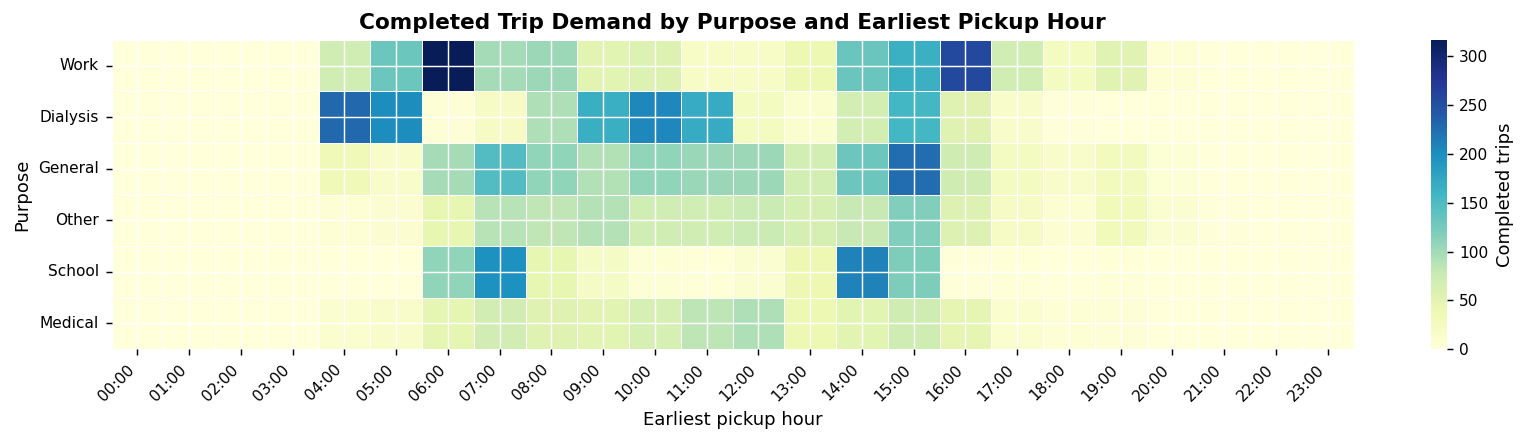

In [6]:
def hour_from_time(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    if not s:
        return np.nan
    try:
        return int(s.split(':')[0])
    except Exception:
        dt = pd.to_datetime(s, errors='coerce')
        return np.nan if pd.isna(dt) else dt.hour

df_time_demand = df_clean.copy()
df_time_demand['pickup_hour'] = df_time_demand['Earliest Pick-up'].apply(hour_from_time)
df_time_demand = df_time_demand.dropna(subset=['Purpose', 'pickup_hour']).copy()
df_time_demand['pickup_hour'] = df_time_demand['pickup_hour'].astype(int)

purpose_hourly_demand = (
    df_time_demand
    .groupby(['Purpose', 'pickup_hour'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=range(24), fill_value=0)
)

purpose_hourly_demand = purpose_hourly_demand.loc[
    purpose_hourly_demand.sum(axis=1).sort_values(ascending=False).index
]

print('Completed-trip demand by earliest pickup hour and purpose:')
display(purpose_hourly_demand.style.format('{:,.0f}'))

fig, ax = plt.subplots(figsize=(13, max(3.5, 0.45 * len(purpose_hourly_demand))))
sns.heatmap(
    purpose_hourly_demand,
    cmap='YlGnBu',
    linewidths=0.4,
    linecolor='white',
    cbar_kws={'label': 'Completed trips'},
    ax=ax,
)
ax.set_title('Completed Trip Demand by Purpose and Earliest Pickup Hour')
ax.set_xlabel('Earliest pickup hour')
ax.set_ylabel('Purpose')
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, ha='right')
plt.tight_layout()


In [7]:
POI_PATH = Path('/scratch/umni5/a/li5125/DOE_analysis/RFI-Rider_flexibility_index-/birmingham_pois.csv')
poi_categories = pd.read_csv(POI_PATH)
poi_categories = poi_categories.dropna(subset=['lat', 'lon']).copy()
poi_categories['poi_name'] = poi_categories['name'].fillna('Unknown POI').astype(str)
poi_categories['poi_top_category'] = poi_categories['top_category'].fillna('Unknown category').astype(str)
poi_categories['poi_sub_category'] = poi_categories['sub_category'].fillna('Unknown sub-category').astype(str)
poi_categories['poi_address'] = poi_categories['address'].fillna('Unknown address').astype(str)


def add_nearest_poi_category(locations, lat_col, lon_col, prefix, max_distance_m=250):
    result = locations.reset_index(drop=True).copy()
    if result.empty:
        return result

    location_coords = np.radians(result[[lat_col, lon_col]].to_numpy(dtype=float))
    poi_coords = np.radians(poi_categories[['lat', 'lon']].to_numpy(dtype=float))

    dlat = location_coords[:, None, 0] - poi_coords[None, :, 0]
    dlon = location_coords[:, None, 1] - poi_coords[None, :, 1]
    haversine_a = (
        np.sin(dlat / 2) ** 2
        + np.cos(location_coords[:, None, 0])
        * np.cos(poi_coords[None, :, 0])
        * np.sin(dlon / 2) ** 2
    )
    distance_m = 2 * np.arcsin(np.sqrt(haversine_a)) * 6_371_000
    nearest_idx = distance_m.argmin(axis=1)
    nearest_distance_m = distance_m[np.arange(len(result)), nearest_idx]
    nearest_pois = poi_categories.iloc[nearest_idx].reset_index(drop=True)
    nearby_mask = nearest_distance_m <= max_distance_m

    result[f'{prefix}_nearest_poi_name'] = nearest_pois['poi_name']
    result[f'{prefix}_nearest_poi_address'] = nearest_pois['poi_address']
    result[f'{prefix}_nearest_poi_distance_m'] = nearest_distance_m
    result[f'{prefix}_poi_top_category'] = np.where(
        nearby_mask,
        nearest_pois['poi_top_category'],
        f'No nearby POI within {max_distance_m}m',
    )
    result[f'{prefix}_poi_sub_category'] = np.where(
        nearby_mask,
        nearest_pois['poi_sub_category'],
        f'No nearby POI within {max_distance_m}m',
    )
    result[f'{prefix}_poi_match_status'] = np.where(
        nearby_mask,
        f'matched within {max_distance_m}m',
        f'nearest POI farther than {max_distance_m}m',
    )
    return result


top_pickup_locations = (
    df_clean
    .groupby(['pickup_address', 'pickup_lat', 'pickup_lon'])
    .agg(
        num_trips=('Trip ID', 'count'),
        num_customers=('Customer Number', 'nunique'),
        num_purposes=('Purpose', 'nunique'),
    )
    .reset_index()
    .sort_values(['num_trips', 'num_customers'], ascending=False)
    .head(20)
)
top_pickup_locations.insert(0, 'rank', range(1, len(top_pickup_locations) + 1))
top_pickup_locations = add_nearest_poi_category(
    top_pickup_locations, 'pickup_lat', 'pickup_lon', 'pickup'
)

top_dropoff_locations = (
    df_clean
    .groupby(['dropoff_address', 'dropoff_lat', 'dropoff_lon'])
    .agg(
        num_trips=('Trip ID', 'count'),
        num_customers=('Customer Number', 'nunique'),
        num_purposes=('Purpose', 'nunique'),
    )
    .reset_index()
    .sort_values(['num_trips', 'num_customers'], ascending=False)
    .head(20)
)
top_dropoff_locations.insert(0, 'rank', range(1, len(top_dropoff_locations) + 1))
top_dropoff_locations = add_nearest_poi_category(
    top_dropoff_locations, 'dropoff_lat', 'dropoff_lon', 'dropoff'
)

top_od_pairs = (
    df_clean
    .groupby([
        'pickup_address', 'pickup_lat', 'pickup_lon',
        'dropoff_address', 'dropoff_lat', 'dropoff_lon',
    ])
    .agg(
        num_trips=('Trip ID', 'count'),
        num_customers=('Customer Number', 'nunique'),
        num_purposes=('Purpose', 'nunique'),
    )
    .reset_index()
    .sort_values(['num_trips', 'num_customers'], ascending=False)
    .head(20)
)
top_od_pairs.insert(0, 'rank', range(1, len(top_od_pairs) + 1))
top_od_pairs = add_nearest_poi_category(top_od_pairs, 'pickup_lat', 'pickup_lon', 'pickup')
top_od_pairs = add_nearest_poi_category(top_od_pairs, 'dropoff_lat', 'dropoff_lon', 'dropoff')

purpose_top_od_pairs = (
    df_clean
    .groupby([
        'Purpose',
        'pickup_address', 'pickup_lat', 'pickup_lon',
        'dropoff_address', 'dropoff_lat', 'dropoff_lon',
    ])
    .agg(
        num_trips=('Trip ID', 'count'),
        num_customers=('Customer Number', 'nunique'),
    )
    .reset_index()
)
purpose_top_od_pairs = purpose_top_od_pairs.sort_values(
    ['Purpose', 'num_trips', 'num_customers'], ascending=[True, False, False]
)
purpose_top_od_pairs['rank_within_purpose'] = (
    purpose_top_od_pairs.groupby('Purpose').cumcount() + 1
)
purpose_top_od_pairs = purpose_top_od_pairs.query('rank_within_purpose <= 5')
purpose_top_od_pairs = add_nearest_poi_category(
    purpose_top_od_pairs, 'pickup_lat', 'pickup_lon', 'pickup'
)
purpose_top_od_pairs = add_nearest_poi_category(
    purpose_top_od_pairs, 'dropoff_lat', 'dropoff_lon', 'dropoff'
)

count_format = {
    'rank': '{:,.0f}',
    'rank_within_purpose': '{:,.0f}',
    'num_trips': '{:,.0f}',
    'num_customers': '{:,.0f}',
    'num_purposes': '{:,.0f}',
    'pickup_lat': '{:.6f}',
    'pickup_lon': '{:.6f}',
    'dropoff_lat': '{:.6f}',
    'dropoff_lon': '{:.6f}',
    'pickup_nearest_poi_distance_m': '{:,.1f}',
    'dropoff_nearest_poi_distance_m': '{:,.1f}',
}

print('Top 20 pickup locations from completed trips with nearest Birmingham POI category:')
display(top_pickup_locations.style.format(count_format))

print('Top 20 drop-off locations from completed trips with nearest Birmingham POI category:')
display(top_dropoff_locations.style.format(count_format))

print('Top 20 OD pairs from completed trips with pickup/drop-off POI categories:')
display(top_od_pairs.style.format(count_format))

print('Top 5 OD pairs within each purpose from completed trips with pickup/drop-off POI categories:')
display(purpose_top_od_pairs.style.format(count_format))



Top 20 pickup locations from completed trips with nearest Birmingham POI category:


,rank,pickup_address,pickup_lat,pickup_lon,num_trips,num_customers,num_purposes,pickup_nearest_poi_name,pickup_nearest_poi_address,pickup_nearest_poi_distance_m,pickup_poi_top_category,pickup_poi_sub_category,pickup_poi_match_status
0,1,"101 Oslo Cir, 35211",33.432659,-86.874540,245,14,5,United Ability,100 Oslo Cir,70.3,Other Schools and Instruction,Sports and Recreation Instruction,matched within 250m
1,2,"120 Oslo Cir, 35211",33.432603,-86.874327,235,13,4,United Ability,100 Oslo Cir,85.1,Other Schools and Instruction,Sports and Recreation Instruction,matched within 250m
2,3,"220 34th St S, 35222",33.519743,-86.783997,211,22,3,Weil Wrecker Service,3400 2nd Ave S,47.8,Automotive Repair and Maintenance,General Automotive Repair,matched within 250m
3,4,"4000 Ridgeway Dr, 35209",33.469278,-86.787902,129,31,4,Union Cemetery,Union Cemetery,"1,597.6",No nearby POI within 250m,No nearby POI within 250m,nearest POI farther than 250m
4,5,"6001 Crestwood Blvd, 35212",33.531142,-86.738915,102,7,4,Alabama Waldorf School,1220 50th St S,86.6,Elementary and Secondary Schools,Elementary and Secondary Schools,matched within 250m
5,6,"708 Cotton Ave SW, 35211",33.490035,-86.856074,88,10,1,Blessed Sacrament Catholic Church,1460 Pearson Ave SW,130.9,Religious Organizations,Religious Organizations,matched within 250m
6,7,"2630 Avenue E, 35218",33.507141,-86.901755,87,9,2,Askew Willie D MD,2512 Avenue E,77.6,Offices of Physicians,Offices of Physicians (except Mental Health Specialists),matched within 250m
7,8,"4736 9th Ave N, 35212",33.539444,-86.764095,79,4,3,Sammy's Sandwich Shop,4921 Messer Airport Hwy,180.1,Restaurants and Other Eating Places,Limited-Service Restaurants,matched within 250m
8,9,"300 22nd St S, 35233",33.511142,-86.799886,75,8,1,DVA Renal Healthcare Inc,300B 22nd St S,25.6,Outpatient Care Centers,Kidney Dialysis Centers,matched within 250m
9,10,"1616 Oxmoor Rd, 35209",33.475003,-86.799030,66,8,5,Starz Karaoke Lounge,730 Valley Ave,"1,526.0",No nearby POI within 250m,No nearby POI within 250m,nearest POI farther than 250m


Top 20 drop-off locations from completed trips with nearest Birmingham POI category:


,rank,dropoff_address,dropoff_lat,dropoff_lon,num_trips,num_customers,num_purposes,dropoff_nearest_poi_name,dropoff_nearest_poi_address,dropoff_nearest_poi_distance_m,dropoff_poi_top_category,dropoff_poi_sub_category,dropoff_poi_match_status
0,1,"220 34th St S, 35222",33.519743,-86.783997,303,23,3,Weil Wrecker Service,3400 2nd Ave S,47.8,Automotive Repair and Maintenance,General Automotive Repair,matched within 250m
1,2,"101 Oslo Cir, 35211",33.432659,-86.874540,242,14,5,United Ability,100 Oslo Cir,70.3,Other Schools and Instruction,Sports and Recreation Instruction,matched within 250m
2,3,"120 Oslo Cir, 35211",33.432603,-86.874327,210,12,3,United Ability,100 Oslo Cir,85.1,Other Schools and Instruction,Sports and Recreation Instruction,matched within 250m
3,4,"4000 Ridgeway Dr, 35209",33.469278,-86.787902,145,34,4,Union Cemetery,Union Cemetery,"1,597.6",No nearby POI within 250m,No nearby POI within 250m,nearest POI farther than 250m
4,5,"6001 Crestwood Blvd, 35212",33.531142,-86.738915,103,7,3,Alabama Waldorf School,1220 50th St S,86.6,Elementary and Secondary Schools,Elementary and Secondary Schools,matched within 250m
5,6,"300 22nd St S, 35233",33.511142,-86.799886,84,8,1,DVA Renal Healthcare Inc,300B 22nd St S,25.6,Outpatient Care Centers,Kidney Dialysis Centers,matched within 250m
6,7,"2630 Avenue E, 35218",33.507141,-86.901755,83,10,1,Askew Willie D MD,2512 Avenue E,77.6,Offices of Physicians,Offices of Physicians (except Mental Health Specialists),matched within 250m
7,8,"708 Cotton Ave SW, 35211",33.490035,-86.856074,83,9,1,Blessed Sacrament Catholic Church,1460 Pearson Ave SW,130.9,Religious Organizations,Religious Organizations,matched within 250m
8,9,"1809 Avenue H, 35218",33.511695,-86.893478,81,7,1,DaVita,1809 Avenue H,31.8,Outpatient Care Centers,Kidney Dialysis Centers,matched within 250m
9,10,"4736 9th Ave N, 35212",33.539444,-86.764095,77,4,4,Sammy's Sandwich Shop,4921 Messer Airport Hwy,180.1,Restaurants and Other Eating Places,Limited-Service Restaurants,matched within 250m


Top 20 OD pairs from completed trips with pickup/drop-off POI categories:


,rank,pickup_address,pickup_lat,pickup_lon,dropoff_address,dropoff_lat,dropoff_lon,num_trips,num_customers,num_purposes,pickup_nearest_poi_name,pickup_nearest_poi_address,pickup_nearest_poi_distance_m,pickup_poi_top_category,pickup_poi_sub_category,pickup_poi_match_status,dropoff_nearest_poi_name,dropoff_nearest_poi_address,dropoff_nearest_poi_distance_m,dropoff_poi_top_category,dropoff_poi_sub_category,dropoff_poi_match_status
0,1,"4736 9th Ave N, 35212",33.539444,-86.764095,"101 Oslo Cir, 35211",33.432659,-86.874540,79,4,3,Sammy's Sandwich Shop,4921 Messer Airport Hwy,180.1,Restaurants and Other Eating Places,Limited-Service Restaurants,matched within 250m,United Ability,100 Oslo Cir,70.3,Other Schools and Instruction,Sports and Recreation Instruction,matched within 250m
1,2,"101 Oslo Cir, 35211",33.432659,-86.874540,"4736 9th Ave N, 35212",33.539444,-86.764095,77,4,4,United Ability,100 Oslo Cir,70.3,Other Schools and Instruction,Sports and Recreation Instruction,matched within 250m,Sammy's Sandwich Shop,4921 Messer Airport Hwy,180.1,Restaurants and Other Eating Places,Limited-Service Restaurants,matched within 250m
2,3,"6004 Crestwood Blvd, 35212",33.531157,-86.738866,"1528 17th Pl SW, 35211",33.476439,-86.859704,41,2,2,Alabama Waldorf School,1220 50th St S,86.0,Elementary and Secondary Schools,Elementary and Secondary Schools,matched within 250m,New Hope Baptist Church,1310 17th Way SW,301.9,No nearby POI within 250m,No nearby POI within 250m,nearest POI farther than 250m
3,4,"101 Oslo Cir, 35211",33.432659,-86.874540,"1556 Cleveland Ave SW, 35211",33.487791,-86.857878,39,2,3,United Ability,100 Oslo Cir,70.3,Other Schools and Instruction,Sports and Recreation Instruction,matched within 250m,Sandy's Flowers,1482 Pearson Ave SW,151.2,Florists,Florists,matched within 250m
4,5,"1556 Cleveland Ave SW, 35211",33.487791,-86.857878,"101 Oslo Cir, 35211",33.432659,-86.874540,39,2,2,Sandy's Flowers,1482 Pearson Ave SW,151.2,Florists,Florists,matched within 250m,United Ability,100 Oslo Cir,70.3,Other Schools and Instruction,Sports and Recreation Instruction,matched within 250m
5,6,"101 Oslo Cir, 35211",33.432659,-86.874540,"1321 13th St S, 35205",33.495546,-86.805594,38,2,2,United Ability,100 Oslo Cir,70.3,Other Schools and Instruction,Sports and Recreation Instruction,matched within 250m,UAB Highlands Apothecary,1201 11th Ave S,98.4,Health and Personal Care Stores,Pharmacies and Drug Stores,matched within 250m
6,7,"220 17th Ave SW, 35211",33.479607,-86.835695,"6004 Crestwood Blvd, 35212",33.531157,-86.738866,38,2,2,Mount Carmel Baptist Church,1705 Goldwire St SW,74.7,Religious Organizations,Religious Organizations,matched within 250m,Alabama Waldorf School,1220 50th St S,86.0,Elementary and Secondary Schools,Elementary and Secondary Schools,matched within 250m
7,8,"1624 5th St NW, 35215",33.629755,-86.696695,"220 34th St S, 35222",33.519743,-86.783997,37,2,2,Patty Cake Academy East,1717 Carson Rd,700.9,No nearby POI within 250m,No nearby POI within 250m,nearest POI farther than 250m,Weil Wrecker Service,3400 2nd Ave S,47.8,Automotive Repair and Maintenance,General Automotive Repair,matched within 250m
8,9,"1321 13th St S, 35205",33.495546,-86.805594,"101 Oslo Cir, 35211",33.432659,-86.874540,35,2,2,UAB Highlands Apothecary,1201 11th Ave S,98.4,Health and Personal Care Stores,Pharmacies and Drug Stores,matched within 250m,United Ability,100 Oslo Cir,70.3,Other Schools and Instruction,Sports and Recreation Instruction,matched within 250m
9,10,"2040 Highland Ave S, 35205",33.499748,-86.794975,"4000 Ridgeway Dr, 35209",33.469278,-86.787902,25,3,3,Cobb Lane Bed and Breakfast,1309 19th St S,28.6,Department Stores,Department Stores,matched within 250m,Union Cemetery,Union Cemetery,"1,597.6",No nearby POI within 250m,No nearby POI within 250m,nearest POI farther than 250m


Top 5 OD pairs within each purpose from completed trips with pickup/drop-off POI categories:


,Purpose,pickup_address,pickup_lat,pickup_lon,dropoff_address,dropoff_lat,dropoff_lon,num_trips,num_customers,rank_within_purpose,pickup_nearest_poi_name,pickup_nearest_poi_address,pickup_nearest_poi_distance_m,pickup_poi_top_category,pickup_poi_sub_category,pickup_poi_match_status,dropoff_nearest_poi_name,dropoff_nearest_poi_address,dropoff_nearest_poi_distance_m,dropoff_poi_top_category,dropoff_poi_sub_category,dropoff_poi_match_status
0,Dialysis,"708 Cotton Ave SW, 35211",33.490035,-86.856074,"2504 Avenue K, 35218",33.504619,-86.894894,14,1,1,Blessed Sacrament Catholic Church,1460 Pearson Ave SW,130.9,Religious Organizations,Religious Organizations,matched within 250m,James Lewis Tennis Center,2800 Avenue K,323.3,No nearby POI within 250m,No nearby POI within 250m,nearest POI farther than 250m
1,Dialysis,"7780 Ludington Ln, 35210",33.531658,-86.719372,"2320 3rd Pl NW, 35215",33.646418,-86.693149,14,1,2,Captain D's Seafood Restaurant,7718 Crestwood Blvd,49.1,Restaurants and Other Eating Places,Full-Service Restaurants,matched within 250m,Erwin Middle Sch,532 23rd Ave NW,583.2,No nearby POI within 250m,No nearby POI within 250m,nearest POI farther than 250m
2,Dialysis,"1425 Montclair Rd, 35213",33.523462,-86.727030,"300 22nd St S, 35233",33.511142,-86.799886,13,1,3,BB&T (Branch Banking and Trust),1500 Montclair Rd,80.7,Depository Credit Intermediation,Commercial Banking,matched within 250m,DVA Renal Healthcare Inc,300B 22nd St S,25.6,Outpatient Care Centers,Kidney Dialysis Centers,matched within 250m
3,Dialysis,"1557 Arthur Shores Dr SW, 35211",33.471467,-86.855528,"9540 Parkway E, 35215",33.595828,-86.694592,13,1,4,Jcceo Cooper Green Child Development Ctr,1501 Arthur Shores Dr SW,101.3,Child Day Care Services,Child Day Care Services,matched within 250m,Conn's,9530 Parkway East Roebuck,9.5,Electronics and Appliance Stores,Electronics Stores,matched within 250m
4,Dialysis,"1620 1st St NW, 35215",33.628773,-86.686929,"2337 1st St Ne, 35215",33.646375,-86.681810,13,1,5,Birmingham Subaru,1501 Center Point Pkwy,430.2,No nearby POI within 250m,No nearby POI within 250m,nearest POI farther than 250m,Erwin Middle Sch,532 23rd Ave NW,"1,622.3",No nearby POI within 250m,No nearby POI within 250m,nearest POI farther than 250m
5,General,"101 Oslo Cir, 35211",33.432659,-86.874540,"4736 9th Ave N, 35212",33.539444,-86.764095,21,1,1,United Ability,100 Oslo Cir,70.3,Other Schools and Instruction,Sports and Recreation Instruction,matched within 250m,Sammy's Sandwich Shop,4921 Messer Airport Hwy,180.1,Restaurants and Other Eating Places,Limited-Service Restaurants,matched within 250m
6,General,"412 Camellia Rd, 35215",33.608170,-86.697774,"620 20th St S, 35233",33.506192,-86.800625,21,1,2,Heartful Echoes,437 Camellia Rd,166.6,Apparel Accessories and Other Apparel Manufacturing,Apparel Accessories and Other Apparel Manufacturing,matched within 250m,Vasu Renga MD,620 20th St S,14.9,Offices of Physicians,Offices of Physicians (except Mental Health Specialists),matched within 250m
7,General,"4736 9th Ave N, 35212",33.539444,-86.764095,"101 Oslo Cir, 35211",33.432659,-86.874540,21,1,3,Sammy's Sandwich Shop,4921 Messer Airport Hwy,180.1,Restaurants and Other Eating Places,Limited-Service Restaurants,matched within 250m,United Ability,100 Oslo Cir,70.3,Other Schools and Instruction,Sports and Recreation Instruction,matched within 250m
8,General,"620 20th St S, 35233",33.506192,-86.800625,"412 Camellia Rd, 35215",33.608170,-86.697774,21,1,4,Vasu Renga MD,620 20th St S,14.9,Offices of Physicians,Offices of Physicians (except Mental Health Specialists),matched within 250m,Heartful Echoes,437 Camellia Rd,166.6,Apparel Accessories and Other Apparel Manufacturing,Apparel Accessories and Other Apparel Manufacturing,matched within 250m
9,General,"1624 5th St NW, 35215",33.629755,-86.696695,"220 34th St S, 35222",33.519743,-86.783997,20,2,5,Patty Cake Academy East,1717 Carson Rd,700.9,No nearby POI within 250m,No nearby POI within 250m,nearest POI farther tha

### Rider Regularity Index

This cell measures how routine each rider's completed-trip behavior is. For each customer, it summarizes trip frequency, unique pickup/drop-off/OD patterns, pickup-hour consistency, purpose consistency, and weekday consistency.

The regularity index is computed as:

```text
Rider_regularity_index = 0.4 * OD_regular_i
                       + 0.3 * time_regular_i
                       + 0.2 * purpose_regular_i
                       + 0.1 * weekday_regular_i
```

where each component is a dominant-share measure. A higher value means the rider tends to repeat the same OD pair, time, purpose, and weekday pattern. This score is later subtracted from the flexibility index because highly regular behavior indicates less flexibility.



Customers in completed-trip regularity analysis: 502
Mean Rider Regularity Index: 0.582; Median: 0.574


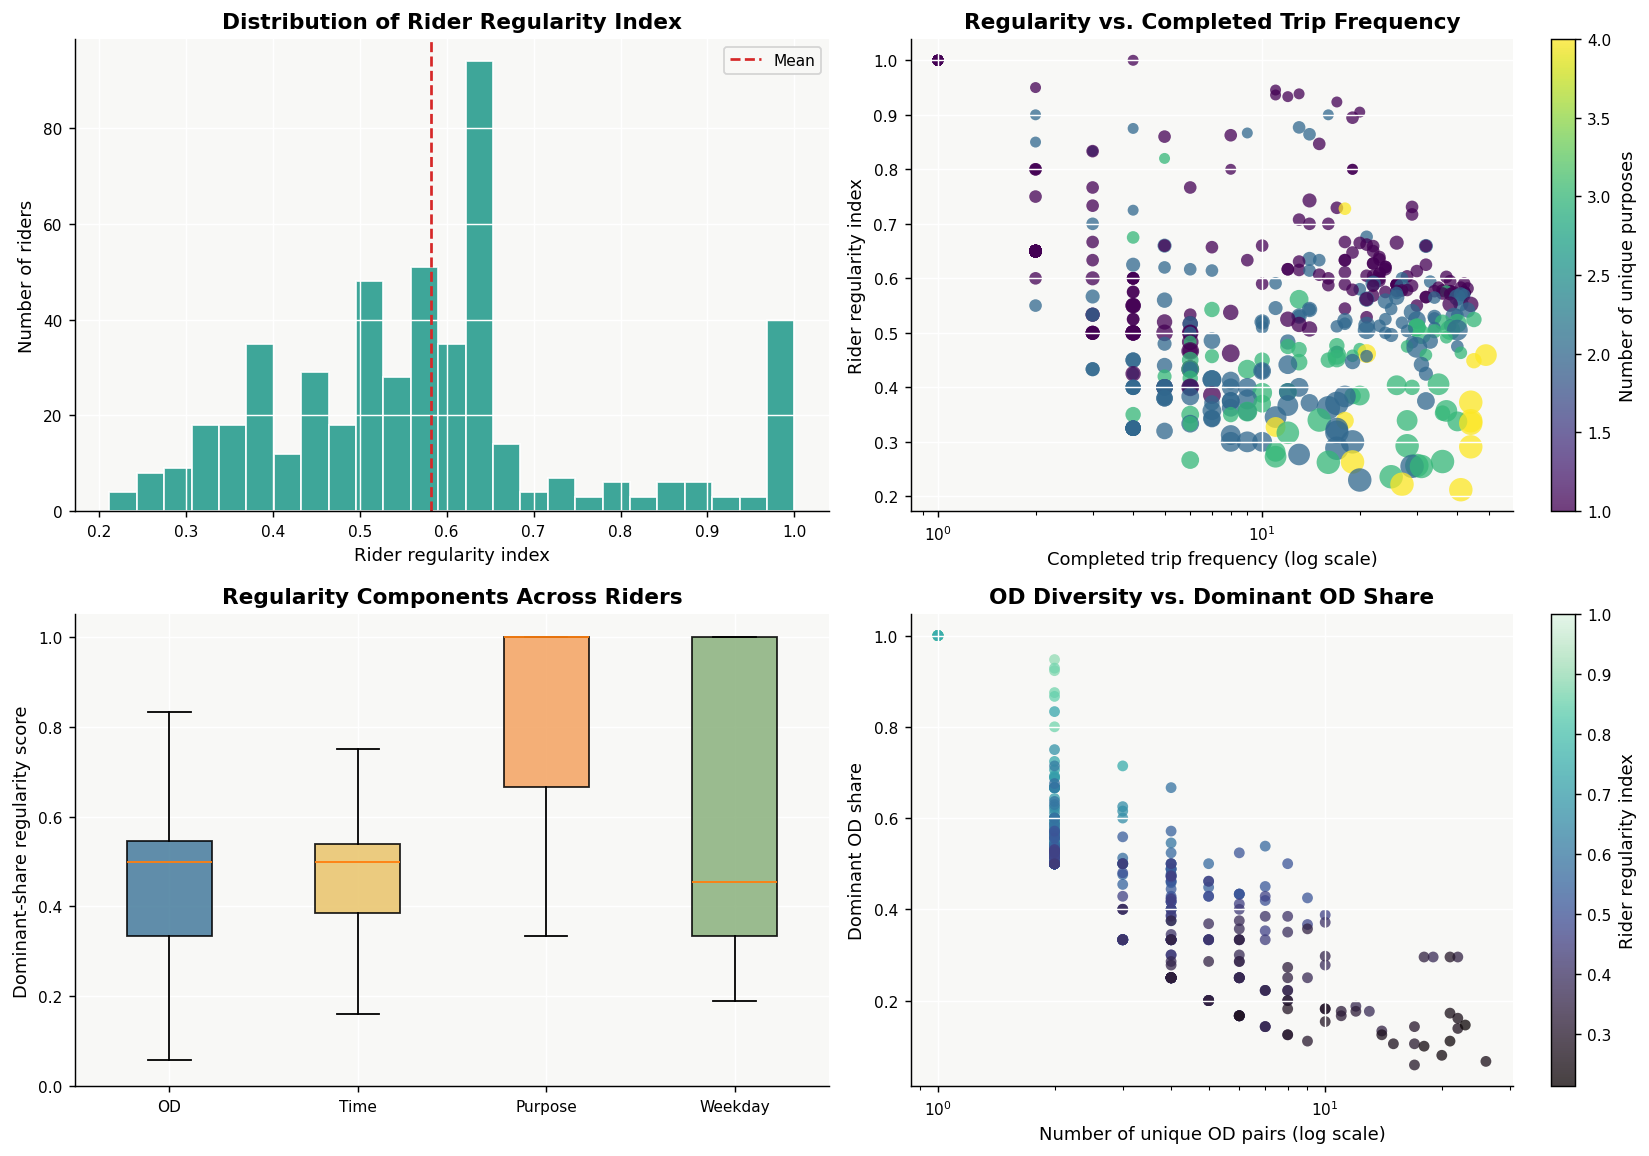

In [8]:
def entropy_from_counts(counts):
    counts = np.asarray(counts, dtype=float)
    total = counts.sum()
    if total == 0:
        return np.nan
    probabilities = counts[counts > 0] / total
    return -(probabilities * np.log2(probabilities)).sum()


def dominant_share(s):
    counts = s.dropna().value_counts()
    if counts.empty:
        return np.nan
    return counts.iloc[0] / counts.sum()


def pickup_hour_std(s):
    values = s.dropna()
    if values.empty:
        return np.nan
    return values.std(ddof=0)


def entropy_for_series(s):
    return entropy_from_counts(s.dropna().value_counts().to_numpy())

rider_trips = df_clean.copy()
rider_trips['pickup_hour'] = rider_trips['Earliest Pick-up'].apply(hour_from_time)
rider_trips['trip_date_parsed'] = pd.to_datetime(rider_trips['Trip Date'], errors='coerce')
rider_trips['weekday'] = rider_trips['trip_date_parsed'].dt.day_name()
rider_trips['pickup_location_key'] = (
    rider_trips[['pickup_address', 'pickup_lat', 'pickup_lon']].astype(str).agg('|'.join, axis=1)
)
rider_trips['dropoff_location_key'] = (
    rider_trips[['dropoff_address', 'dropoff_lat', 'dropoff_lon']].astype(str).agg('|'.join, axis=1)
)
rider_trips['od_pair_key'] = (
    rider_trips['pickup_location_key'] + ' -> ' + rider_trips['dropoff_location_key']
)

rider_regularity = (
    rider_trips
    .groupby('Customer Number')
    .agg(
        trip_frequency=('Trip ID', 'count'),
        num_unique_pickups=('pickup_location_key', 'nunique'),
        num_unique_dropoffs=('dropoff_location_key', 'nunique'),
        num_unique_OD_pairs=('od_pair_key', 'nunique'),
        dominant_OD_share=('od_pair_key', dominant_share),
        pickup_hour_std=('pickup_hour', pickup_hour_std),
        dominant_pickup_hour_share=('pickup_hour', dominant_share),
        time_entropy=('pickup_hour', entropy_for_series),
        num_unique_purposes=('Purpose', 'nunique'),
        dominant_purpose_share=('Purpose', dominant_share),
        num_active_weekdays=('weekday', 'nunique'),
        dominant_weekday_share=('weekday', dominant_share),
        weekday_entropy=('weekday', entropy_for_series),
    )
    .reset_index()
)

rider_regularity['OD_regular_i'] = rider_regularity['dominant_OD_share']
rider_regularity['time_regular_i'] = rider_regularity['dominant_pickup_hour_share']
rider_regularity['purpose_regular_i'] = rider_regularity['dominant_purpose_share']
rider_regularity['weekday_regular_i'] = rider_regularity['dominant_weekday_share']
rider_regularity['Rider_regularity_index'] = (
    0.4 * rider_regularity['OD_regular_i']
    + 0.3 * rider_regularity['time_regular_i']
    + 0.2 * rider_regularity['purpose_regular_i']
    + 0.1 * rider_regularity['weekday_regular_i']
)

rider_regularity = rider_regularity.sort_values(
    ['Rider_regularity_index', 'trip_frequency'], ascending=[False, False]
)

print(f"Customers in completed-trip regularity analysis: {len(rider_regularity):,}")
print(
    f"Mean Rider Regularity Index: {rider_regularity['Rider_regularity_index'].mean():.3f}; "
    f"Median: {rider_regularity['Rider_regularity_index'].median():.3f}"
)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0, 0].hist(
    rider_regularity['Rider_regularity_index'],
    bins=25,
    color='#2a9d8f',
    edgecolor='white',
    alpha=0.9,
)
axes[0, 0].axvline(
    rider_regularity['Rider_regularity_index'].mean(),
    color='#d62828',
    linestyle='--',
    linewidth=1.5,
    label='Mean',
)
axes[0, 0].set_title('Distribution of Rider Regularity Index')
axes[0, 0].set_xlabel('Rider regularity index')
axes[0, 0].set_ylabel('Number of riders')
axes[0, 0].legend()

scatter_1 = axes[0, 1].scatter(
    rider_regularity['trip_frequency'],
    rider_regularity['Rider_regularity_index'],
    c=rider_regularity['num_unique_purposes'],
    s=25 + 12 * rider_regularity['num_unique_OD_pairs'].clip(upper=12),
    cmap='viridis',
    alpha=0.75,
    edgecolors='none',
)
axes[0, 1].set_xscale('log')
axes[0, 1].set_title('Regularity vs. Completed Trip Frequency')
axes[0, 1].set_xlabel('Completed trip frequency (log scale)')
axes[0, 1].set_ylabel('Rider regularity index')
fig.colorbar(scatter_1, ax=axes[0, 1], label='Number of unique purposes')

component_data = [
    rider_regularity['OD_regular_i'].dropna(),
    rider_regularity['time_regular_i'].dropna(),
    rider_regularity['purpose_regular_i'].dropna(),
    rider_regularity['weekday_regular_i'].dropna(),
]
box = axes[1, 0].boxplot(
    component_data,
    labels=['OD', 'Time', 'Purpose', 'Weekday'],
    patch_artist=True,
    showfliers=False,
)
for patch, color in zip(box['boxes'], ['#457b9d', '#e9c46a', '#f4a261', '#8ab17d']):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
axes[1, 0].set_title('Regularity Components Across Riders')
axes[1, 0].set_ylabel('Dominant-share regularity score')
axes[1, 0].set_ylim(0, 1.05)

scatter_2 = axes[1, 1].scatter(
    rider_regularity['num_unique_OD_pairs'],
    rider_regularity['dominant_OD_share'],
    c=rider_regularity['Rider_regularity_index'],
    cmap='mako' if 'mako' in plt.colormaps() else 'viridis',
    alpha=0.75,
    edgecolors='none',
)
axes[1, 1].set_xscale('log')
axes[1, 1].set_title('OD Diversity vs. Dominant OD Share')
axes[1, 1].set_xlabel('Number of unique OD pairs (log scale)')
axes[1, 1].set_ylabel('Dominant OD share')
fig.colorbar(scatter_2, ax=axes[1, 1], label='Rider regularity index')

plt.tight_layout()
plt.show()



### Actual Pickup Time From Vehicle Route Events

This cell links completed trips to `vehicle_tour_segments.csv` to recover route-event pickup times. Pickup events are identified where `event_at_start == 'PICKUP'` and are matched to trips using customer, date, run/vehicle, and pickup-coordinate proximity.

The resulting fields include `actual_pickup_timestamp`, `actual_pickup_time`, and `actual_pickup_hour`. In this dataset, the matched actual pickup time is almost always equal to `Earliest Pick-up`, so the pickup deviation term has limited variation.



In [9]:
ROUTE_SEGMENTS_PATH = Path('/scratch/umni5/a/li5125/DOE_analysis/RFI-Rider_flexibility_index-/vehicle_tour_segments.csv')
vehicle_segments = pd.read_csv(ROUTE_SEGMENTS_PATH, low_memory=False)

pickup_events = vehicle_segments[
    vehicle_segments['event_at_start'].astype('string').str.upper().eq('PICKUP')
].copy()
pickup_events['trip_date_key'] = pd.to_datetime(pickup_events['Date/Time'], errors='coerce').dt.date
pickup_events['customer_key'] = pd.to_numeric(pickup_events['rider_at_start'], errors='coerce')
pickup_events['run_key'] = pd.to_numeric(pickup_events['Vehicle'], errors='coerce')
pickup_events['actual_pickup_timestamp'] = pd.to_datetime(
    pickup_events['Date/Time'].astype(str).str[:10] + ' ' + pickup_events['Depart'].astype(str),
    errors='coerce',
)
pickup_events = pickup_events.dropna(
    subset=['trip_date_key', 'customer_key', 'run_key', 'actual_pickup_timestamp', 'StartLatitude', 'StartLongitude']
).copy()
pickup_events = pickup_events.reset_index().rename(columns={'index': 'pickup_event_id'})

trips_for_actual_pickup = df_clean.copy()
trips_for_actual_pickup['trip_date_key'] = pd.to_datetime(
    trips_for_actual_pickup['Trip Date'], errors='coerce'
).dt.date
trips_for_actual_pickup['customer_key'] = pd.to_numeric(
    trips_for_actual_pickup['Customer Number'], errors='coerce'
)
trips_for_actual_pickup['run_key'] = pd.to_numeric(trips_for_actual_pickup['Run ID'], errors='coerce')
trips_for_actual_pickup['scheduled_pickup_timestamp'] = pd.to_datetime(
    trips_for_actual_pickup['Trip Date'].astype(str) + ' ' + trips_for_actual_pickup['Earliest Pick-up'].astype(str),
    errors='coerce',
)

pickup_candidates = trips_for_actual_pickup.merge(
    pickup_events[[
        'pickup_event_id', 'trip_date_key', 'customer_key', 'run_key',
        'actual_pickup_timestamp', 'Depart', 'StartLatitude', 'StartLongitude',
        'trip_ids_on_board', 'next_action',
    ]],
    on=['trip_date_key', 'customer_key', 'run_key'],
    how='left',
)

# Distance between trip pickup coordinate and route-event start coordinate.
pickup_candidates['pickup_event_distance_m'] = np.nan
matched_candidate_mask = pickup_candidates['pickup_event_id'].notna()
if matched_candidate_mask.any():
    lat1 = np.radians(pickup_candidates.loc[matched_candidate_mask, 'pickup_lat'].astype(float))
    lon1 = np.radians(pickup_candidates.loc[matched_candidate_mask, 'pickup_lon'].astype(float))
    lat2 = np.radians(pickup_candidates.loc[matched_candidate_mask, 'StartLatitude'].astype(float))
    lon2 = np.radians(pickup_candidates.loc[matched_candidate_mask, 'StartLongitude'].astype(float))
    haversine_a = (
        np.sin((lat1 - lat2) / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin((lon1 - lon2) / 2) ** 2
    )
    pickup_candidates.loc[matched_candidate_mask, 'pickup_event_distance_m'] = (
        2 * np.arcsin(np.sqrt(haversine_a)) * 6_371_000
    )

pickup_candidates['actual_vs_scheduled_pickup_min'] = (
    pickup_candidates['actual_pickup_timestamp']
    - pickup_candidates['scheduled_pickup_timestamp']
).dt.total_seconds() / 60
pickup_candidates['abs_actual_vs_scheduled_pickup_min'] = (
    pickup_candidates['actual_vs_scheduled_pickup_min'].abs()
)

best_pickup_matches = (
    pickup_candidates
    .dropna(subset=['pickup_event_id'])
    .sort_values([
        'Trip ID', 'pickup_event_distance_m', 'abs_actual_vs_scheduled_pickup_min'
    ])
    .drop_duplicates('Trip ID')
)
best_pickup_matches = best_pickup_matches[
    best_pickup_matches['pickup_event_distance_m'] <= 150
].copy()

actual_pickup_lookup = best_pickup_matches.set_index('Trip ID')[[
    'actual_pickup_timestamp', 'pickup_event_distance_m', 'actual_vs_scheduled_pickup_min',
    'pickup_event_id', 'trip_ids_on_board', 'next_action',
]]

actual_pickup_cols = [
    'actual_pickup_timestamp', 'pickup_event_distance_m', 'actual_vs_scheduled_pickup_min',
    'pickup_event_id', 'trip_ids_on_board', 'next_action',
    'actual_pickup_time', 'actual_pickup_hour',
]
df_clean = df_clean.drop(columns=[c for c in actual_pickup_cols if c in df_clean.columns])

df_clean = df_clean.merge(
    actual_pickup_lookup,
    left_on='Trip ID',
    right_index=True,
    how='left',
)
df_clean['actual_pickup_time'] = df_clean['actual_pickup_timestamp'].dt.strftime('%H:%M:%S')
df_clean['actual_pickup_hour'] = df_clean['actual_pickup_timestamp'].dt.hour

matched_trips = df_clean['actual_pickup_timestamp'].notna().sum()
print(f"Vehicle pickup events: {len(pickup_events):,}")
print(f"Completed trips with matched actual pickup time: {matched_trips:,} / {len(df_clean):,} ({matched_trips / len(df_clean):.1%})")
print(f"Median pickup-coordinate match distance: {df_clean['pickup_event_distance_m'].median():.1f} meters")
print(f"Median actual minus scheduled earliest pickup: {df_clean['actual_vs_scheduled_pickup_min'].median():.1f} minutes")

actual_pickup_summary = df_clean[[
    'Customer Number', 'Trip ID', 'Trip Date', 'Run ID', 'Purpose',
    'Earliest Pick-up', 'actual_pickup_time', 'actual_pickup_hour',
    'actual_vs_scheduled_pickup_min', 'pickup_event_distance_m',
    'pickup_address', 'dropoff_address',
]].sort_values(['Trip Date', 'Run ID', 'actual_pickup_time'])

display(actual_pickup_summary.head(20).style.format({
    'actual_vs_scheduled_pickup_min': '{:,.1f}',
    'pickup_event_distance_m': '{:,.1f}',
}))




Vehicle pickup events: 77,719
Completed trips with matched actual pickup time: 6,008 / 6,857 (87.6%)
Median pickup-coordinate match distance: 0.0 meters
Median actual minus scheduled earliest pickup: 0.0 minutes


,Customer Number,Trip ID,Trip Date,Run ID,Purpose,Earliest Pick-up,actual_pickup_time,actual_pickup_hour,actual_vs_scheduled_pickup_min,pickup_event_distance_m,pickup_address,dropoff_address
4,3523,349278,6/1/22,101,Dialysis,4:25,04:25:00,4.000000,0.0,0.0,"151 Aspen Valley, 35209","3201 3rd Ave S, 35222"
11,9214,346975,6/1/22,101,Dialysis,4:33,04:33:00,4.000000,0.0,0.0,"3367 33rd St N, 35207","1917 32nd Ave N, 35207"
18,5277,345728,6/1/22,101,Dialysis,5:00,05:00:00,5.000000,0.0,0.0,"100 Pratt Hwy, 35214","3007 27th St N, 35207"
20,2701,345685,6/1/22,101,Work,5:00,05:00:00,5.000000,0.0,0.0,"1909 30th Ave N, 35207","103 Shades Creek Circle, 35211"
24,4825,347063,6/1/22,101,Dialysis,5:12,05:12:00,5.000000,0.0,0.0,"2504 Avenue K, 35218","708 Cotton Ave SW, 35211"
31,2907,345696,6/1/22,101,Dialysis,5:30,05:30:00,5.000000,0.0,0.1,"1821 30th St, 35208","708 Cotton Ave SW, 35211"
69,9259,346838,6/1/22,101,Medical,6:32,06:32:00,6.000000,0.0,0.1,"5020 Juanita Cir, 35228","35243 Grandview Pkwy, 35243"
136,2881,350003,6/1/22,101,Work,7:59,07:59:00,7.000000,0.0,0.0,"1324 13th St S, 35205","2101 Richard Arrington Jr Blvd N, 35203"
149,6044,349324,6/1/22,101,General,8:06,08:06:00,8.000000,0.0,0.0,"301 Ave T, 35214","312 Palisades Blvd, 35209"
184,5845,349946,6/1/22,101,School,8:50,08:50:00,8.000000,0.0,0.0,"5321 Ct Q, 35208","1270 Montgomery Highway, 35216"


### Temporal Flexibility Index

This cell computes a rider-level temporal flexibility score from two pieces:

```text
E_i = actual_pickup_time_i - earliest_pickup_time_i
```

For each customer, the cell calculates the average pickup deviation `average_E_i_min` and the entropy of that customer's earliest pickup-hour distribution.

```text
temporal_flexibility_index = average_E_i_min + earliest_pickup_time_entropy
```

The entropy term captures how spread out a rider's requested pickup times are. Since actual pickup and earliest pickup are nearly identical here, most temporal variation comes from pickup-time entropy rather than `E_i`.



Trips with E_i available: 6,008 / 6,857
Customers with temporal flexibility index: 499


,Customer Number,trip_frequency,matched_actual_pickup_trips,average_E_i_min,median_E_i_min,earliest_pickup_time_entropy,num_unique_earliest_pickup_hours,actual_pickup_match_rate,temporal_flexibility_index
339,5348,27,27,0.00,0.00,3.56,13,100.0%,3.56
364,5536,20,20,0.00,0.00,3.38,11,100.0%,3.38
324,5148,25,24,0.00,0.00,3.30,11,96.0%,3.30
300,4749,44,44,0.00,0.00,3.30,13,100.0%,3.30
281,4353,13,13,0.00,0.00,3.24,10,100.0%,3.24
129,3183,41,41,0.00,0.00,3.21,11,100.0%,3.21
182,3537,14,13,0.00,0.00,3.18,10,92.9%,3.18
460,9112,32,30,0.00,0.00,3.18,11,93.8%,3.18
41,2061,17,17,0.00,0.00,3.15,10,100.0%,3.15
98,2987,29,29,0.00,0.00,3.14,10,100.0%,3.14


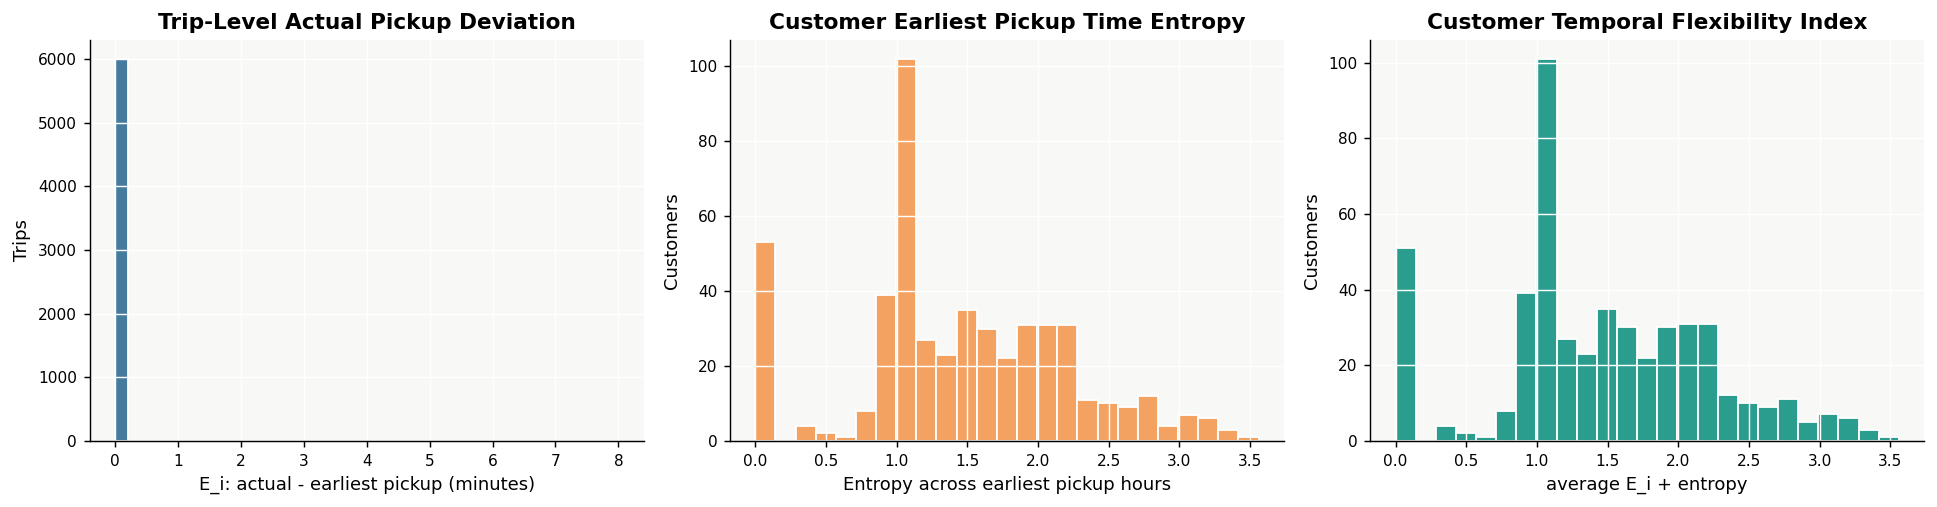

In [10]:
temporal_flexibility_trips = df_clean.copy()
temporal_flexibility_trips['earliest_pickup_timestamp'] = pd.to_datetime(
    temporal_flexibility_trips['Trip Date'].astype(str)
    + ' '
    + temporal_flexibility_trips['Earliest Pick-up'].astype(str),
    errors='coerce',
)
temporal_flexibility_trips['earliest_pickup_hour'] = (
    temporal_flexibility_trips['Earliest Pick-up'].apply(hour_from_time)
)

# E_i is measured in minutes: actual pickup time minus requested earliest pickup time.
temporal_flexibility_trips['E_i_actual_minus_earliest_pickup_min'] = (
    temporal_flexibility_trips['actual_pickup_timestamp']
    - temporal_flexibility_trips['earliest_pickup_timestamp']
).dt.total_seconds() / 60

def entropy_bits(s):
    counts = s.dropna().value_counts().to_numpy(dtype=float)
    total = counts.sum()
    if total == 0:
        return np.nan
    probabilities = counts[counts > 0] / total
    return -(probabilities * np.log2(probabilities)).sum()

customer_temporal_flexibility = (
    temporal_flexibility_trips
    .groupby('Customer Number')
    .agg(
        trip_frequency=('Trip ID', 'count'),
        matched_actual_pickup_trips=('actual_pickup_timestamp', 'count'),
        average_E_i_min=('E_i_actual_minus_earliest_pickup_min', 'mean'),
        median_E_i_min=('E_i_actual_minus_earliest_pickup_min', 'median'),
        earliest_pickup_time_entropy=('earliest_pickup_hour', entropy_bits),
        num_unique_earliest_pickup_hours=('earliest_pickup_hour', 'nunique'),
    )
    .reset_index()
)
customer_temporal_flexibility['actual_pickup_match_rate'] = (
    customer_temporal_flexibility['matched_actual_pickup_trips']
    / customer_temporal_flexibility['trip_frequency']
)
customer_temporal_flexibility['temporal_flexibility_index'] = (
    customer_temporal_flexibility['average_E_i_min']
    + customer_temporal_flexibility['earliest_pickup_time_entropy']
)
customer_temporal_flexibility = customer_temporal_flexibility.sort_values(
    ['temporal_flexibility_index', 'trip_frequency'], ascending=[False, False]
)

print(
    f"Trips with E_i available: "
    f"{temporal_flexibility_trips['E_i_actual_minus_earliest_pickup_min'].notna().sum():,} / "
    f"{len(temporal_flexibility_trips):,}"
)
print(f"Customers with temporal flexibility index: {customer_temporal_flexibility['temporal_flexibility_index'].notna().sum():,}")

display(customer_temporal_flexibility.head(20).style.format({
    'trip_frequency': '{:,.0f}',
    'matched_actual_pickup_trips': '{:,.0f}',
    'actual_pickup_match_rate': '{:.1%}',
    'average_E_i_min': '{:,.2f}',
    'median_E_i_min': '{:,.2f}',
    'earliest_pickup_time_entropy': '{:,.2f}',
    'num_unique_earliest_pickup_hours': '{:,.0f}',
    'temporal_flexibility_index': '{:,.2f}',
}))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(
    temporal_flexibility_trips['E_i_actual_minus_earliest_pickup_min'].dropna(),
    bins=40,
    color='#457b9d',
    edgecolor='white',
)
axes[0].set_title('Trip-Level Actual Pickup Deviation')
axes[0].set_xlabel('E_i: actual - earliest pickup (minutes)')
axes[0].set_ylabel('Trips')

axes[1].hist(
    customer_temporal_flexibility['earliest_pickup_time_entropy'].dropna(),
    bins=25,
    color='#f4a261',
    edgecolor='white',
)
axes[1].set_title('Customer Earliest Pickup Time Entropy')
axes[1].set_xlabel('Entropy across earliest pickup hours')
axes[1].set_ylabel('Customers')

axes[2].hist(
    customer_temporal_flexibility['temporal_flexibility_index'].dropna(),
    bins=25,
    color='#2a9d8f',
    edgecolor='white',
)
axes[2].set_title('Customer Temporal Flexibility Index')
axes[2].set_xlabel('average E_i + entropy')
axes[2].set_ylabel('Customers')

plt.tight_layout()
plt.show()


I found that all routes have the same pickup time with the earliest pickup time.

### Geographical Flexibility Index

This cell measures how spatially flexible each rider's completed destinations are. It combines three components:

```text
GF_r = 0.3 * destination_diversity_score
     + 0.3 * destination_radius_score_norm
     + 0.4 * alternative_location_availability_score
```

`destination_diversity_score` is normalized entropy over the rider's drop-off destination zones, using drop-off addresses before CBG zones are created. `destination_radius_score_norm` measures how spread out the rider's destinations are around their average destination center. `alternative_location_availability_score` uses `birmingham_pois.csv` to count similar nearby POIs within the selected buffer.

A higher score means the rider has more diverse destinations, travels across a wider destination area, and/or tends to visit locations with more nearby substitutes.



Customers in geographical flexibility analysis: 502
Unique destination locations: 852
Destination locations with POI category within 250m: 543 / 852


,Customer Number,trip_frequency,num_unique_destinations,destination_diversity_score,destination_radius_m,alternative_location_availability_score,avg_similar_pois_within_800m,num_destination_poi_categories,dominant_destination_poi_category,destination_radius_score_norm,geographical_flexibility_index
469,9183,3,3,1.000,"4,786.4",0.731,57.0,3,Offices of Physicians,0.324,0.689
185,3569,42,2,1.000,"7,406.3",0.551,48.5,2,Offices of Physicians,0.502,0.671
487,9317,4,2,1.000,"11,276.9",0.302,8.5,2,Drinking Places (Alcoholic Beverages),0.764,0.650
163,3417,32,2,0.954,"2,434.2",0.774,74.1,2,Offices of Physicians,0.165,0.646
32,1780,32,2,0.989,"11,786.8",0.271,5.1,2,Automotive Repair and Maintenance,0.798,0.645
356,5479,6,4,0.896,"14,763.2",0.177,1.8,3,Child Day Care Services,1.000,0.640
97,2978,4,3,0.946,"10,440.9",0.349,6.8,3,Child Day Care Services,0.707,0.636
404,6014,6,2,1.000,"8,609.8",0.391,7.5,2,Offices of Dentists,0.583,0.631
381,5713,26,2,1.000,"5,395.2",0.549,47.5,2,Restaurants and Other Eating Places,0.365,0.629
147,3295,42,2,1.000,"14,497.9",0.073,0.5,2,Other Schools and Instruction,0.982,0.624


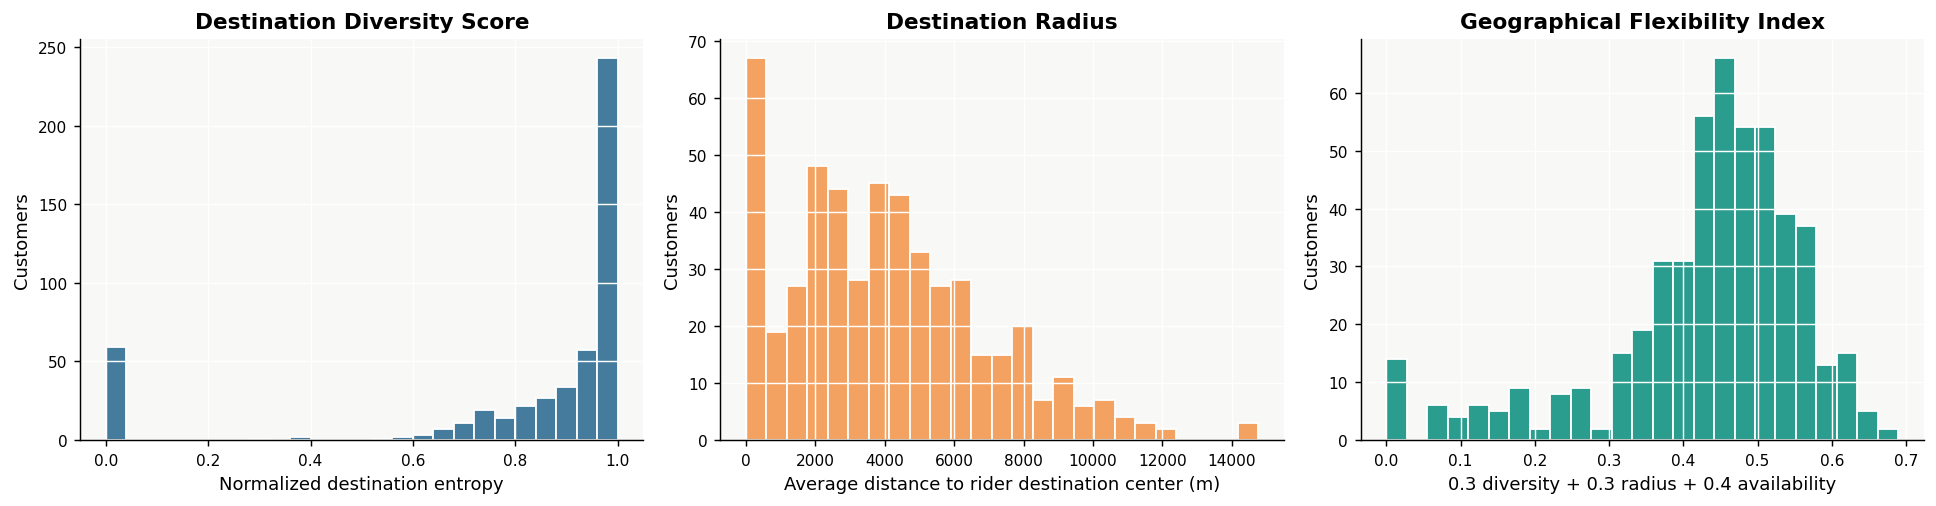

In [13]:
POI_PATH = Path('/scratch/umni5/a/li5125/DOE_analysis/RFI-Rider_flexibility_index-/birmingham_pois.csv')
poi_geo = pd.read_csv(POI_PATH)
poi_geo = poi_geo.dropna(subset=['lat', 'lon', 'top_category']).copy()
poi_geo['poi_top_category'] = poi_geo['top_category'].fillna('Unknown category').astype(str)
poi_geo['poi_sub_category'] = poi_geo['sub_category'].fillna('Unknown sub-category').astype(str)
poi_geo['poi_name'] = poi_geo['name'].fillna('Unknown POI').astype(str)

ALTERNATIVE_RADIUS_M = 800
NEAREST_POI_MATCH_RADIUS_M = 250
SELF_POI_EXCLUSION_RADIUS_M = 25


def haversine_matrix_m(lat1, lon1, lat2, lon2):
    lat1 = np.radians(np.asarray(lat1, dtype=float))[:, None]
    lon1 = np.radians(np.asarray(lon1, dtype=float))[:, None]
    lat2 = np.radians(np.asarray(lat2, dtype=float))[None, :]
    lon2 = np.radians(np.asarray(lon2, dtype=float))[None, :]
    haversine_a = (
        np.sin((lat1 - lat2) / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin((lon1 - lon2) / 2) ** 2
    )
    return 2 * np.arcsin(np.sqrt(haversine_a)) * 6_371_000


def normalized_entropy(s):
    counts = s.dropna().value_counts().to_numpy(dtype=float)
    if len(counts) <= 1:
        return 0.0
    probabilities = counts / counts.sum()
    entropy = -(probabilities * np.log(probabilities)).sum()
    return entropy / np.log(len(counts))


geography_trips = df_clean.copy()
geography_trips['destination_zone'] = geography_trips['dropoff_address'].astype(str)

unique_destinations = (
    geography_trips[['dropoff_address', 'dropoff_lat', 'dropoff_lon']]
    .drop_duplicates()
    .reset_index(drop=True)
)

poi_distances_m = haversine_matrix_m(
    unique_destinations['dropoff_lat'],
    unique_destinations['dropoff_lon'],
    poi_geo['lat'],
    poi_geo['lon'],
)
nearest_poi_idx = poi_distances_m.argmin(axis=1)
nearest_poi_distance_m = poi_distances_m[np.arange(len(unique_destinations)), nearest_poi_idx]
nearest_pois = poi_geo.iloc[nearest_poi_idx].reset_index(drop=True)
matched_nearest_poi = nearest_poi_distance_m <= NEAREST_POI_MATCH_RADIUS_M

unique_destinations['nearest_poi_name'] = nearest_pois['poi_name']
unique_destinations['nearest_poi_top_category'] = np.where(
    matched_nearest_poi,
    nearest_pois['poi_top_category'],
    'No nearby POI category',
)
unique_destinations['nearest_poi_sub_category'] = np.where(
    matched_nearest_poi,
    nearest_pois['poi_sub_category'],
    'No nearby POI sub-category',
)
unique_destinations['nearest_poi_distance_m'] = nearest_poi_distance_m

alternative_counts = np.zeros(len(unique_destinations), dtype=int)
poi_categories_array = poi_geo['poi_top_category'].to_numpy()
for i, category in enumerate(unique_destinations['nearest_poi_top_category']):
    if category == 'No nearby POI category':
        continue
    same_category = poi_categories_array == category
    nearby_same_category = poi_distances_m[i, same_category] <= ALTERNATIVE_RADIUS_M
    not_self_location = poi_distances_m[i, same_category] > SELF_POI_EXCLUSION_RADIUS_M
    alternative_counts[i] = int((nearby_same_category & not_self_location).sum())

unique_destinations['similar_pois_within_radius'] = alternative_counts
max_alternative_count = unique_destinations['similar_pois_within_radius'].max()
if max_alternative_count > 0:
    unique_destinations['alternative_location_score'] = (
        np.log1p(unique_destinations['similar_pois_within_radius'])
        / np.log1p(max_alternative_count)
    )
else:
    unique_destinations['alternative_location_score'] = 0.0

geography_trips = geography_trips.merge(
    unique_destinations[[
        'dropoff_address', 'dropoff_lat', 'dropoff_lon',
        'nearest_poi_name', 'nearest_poi_top_category', 'nearest_poi_sub_category',
        'nearest_poi_distance_m', 'similar_pois_within_radius', 'alternative_location_score',
    ]],
    on=['dropoff_address', 'dropoff_lat', 'dropoff_lon'],
    how='left',
)

rider_destination_center = (
    geography_trips
    .groupby('Customer Number')
    .agg(
        destination_center_lat=('dropoff_lat', 'mean'),
        destination_center_lon=('dropoff_lon', 'mean'),
    )
    .reset_index()
)
geography_trips = geography_trips.merge(rider_destination_center, on='Customer Number', how='left')

lat1 = np.radians(geography_trips['dropoff_lat'].astype(float))
lon1 = np.radians(geography_trips['dropoff_lon'].astype(float))
lat2 = np.radians(geography_trips['destination_center_lat'].astype(float))
lon2 = np.radians(geography_trips['destination_center_lon'].astype(float))
haversine_a = (
    np.sin((lat1 - lat2) / 2) ** 2
    + np.cos(lat1) * np.cos(lat2) * np.sin((lon1 - lon2) / 2) ** 2
)
geography_trips['destination_distance_to_center_m'] = 2 * np.arcsin(np.sqrt(haversine_a)) * 6_371_000

customer_geographical_flexibility = (
    geography_trips
    .groupby('Customer Number')
    .agg(
        trip_frequency=('Trip ID', 'count'),
        num_unique_destinations=('destination_zone', 'nunique'),
        destination_diversity_score=('destination_zone', normalized_entropy),
        destination_radius_m=('destination_distance_to_center_m', 'mean'),
        alternative_location_availability_score=('alternative_location_score', 'mean'),
        avg_similar_pois_within_800m=('similar_pois_within_radius', 'mean'),
        num_destination_poi_categories=('nearest_poi_top_category', 'nunique'),
        dominant_destination_poi_category=('nearest_poi_top_category', lambda s: s.value_counts().index[0] if not s.value_counts().empty else np.nan),
    )
    .reset_index()
)

max_destination_radius = customer_geographical_flexibility['destination_radius_m'].max()
if max_destination_radius > 0:
    customer_geographical_flexibility['destination_radius_score_norm'] = (
        customer_geographical_flexibility['destination_radius_m'] / max_destination_radius
    )
else:
    customer_geographical_flexibility['destination_radius_score_norm'] = 0.0

customer_geographical_flexibility['geographical_flexibility_index'] = (
    0.3 * customer_geographical_flexibility['destination_diversity_score']
    + 0.3 * customer_geographical_flexibility['destination_radius_score_norm']
    + 0.4 * customer_geographical_flexibility['alternative_location_availability_score']
)

customer_geographical_flexibility = customer_geographical_flexibility.sort_values(
    ['geographical_flexibility_index', 'trip_frequency'], ascending=[False, False]
)

print(f"Customers in geographical flexibility analysis: {len(customer_geographical_flexibility):,}")
print(f"Unique destination locations: {len(unique_destinations):,}")
print(
    f"Destination locations with POI category within {NEAREST_POI_MATCH_RADIUS_M}m: "
    f"{(unique_destinations['nearest_poi_top_category'] != 'No nearby POI category').sum():,} / {len(unique_destinations):,}"
)

display(customer_geographical_flexibility.head(20).style.format({
    'trip_frequency': '{:,.0f}',
    'num_unique_destinations': '{:,.0f}',
    'destination_diversity_score': '{:.3f}',
    'destination_radius_m': '{:,.1f}',
    'destination_radius_score_norm': '{:.3f}',
    'alternative_location_availability_score': '{:.3f}',
    'avg_similar_pois_within_800m': '{:,.1f}',
    'num_destination_poi_categories': '{:,.0f}',
    'geographical_flexibility_index': '{:.3f}',
}))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(
    customer_geographical_flexibility['destination_diversity_score'].dropna(),
    bins=25,
    color='#457b9d',
    edgecolor='white',
)
axes[0].set_title('Destination Diversity Score')
axes[0].set_xlabel('Normalized destination entropy')
axes[0].set_ylabel('Customers')

axes[1].hist(
    customer_geographical_flexibility['destination_radius_m'].dropna(),
    bins=25,
    color='#f4a261',
    edgecolor='white',
)
axes[1].set_title('Destination Radius')
axes[1].set_xlabel('Average distance to rider destination center (m)')
axes[1].set_ylabel('Customers')

axes[2].hist(
    customer_geographical_flexibility['geographical_flexibility_index'].dropna(),
    bins=25,
    color='#2a9d8f',
    edgecolor='white',
)
axes[2].set_title('Geographical Flexibility Index')
axes[2].set_xlabel('0.3 diversity + 0.3 radius + 0.4 availability')
axes[2].set_ylabel('Customers')

plt.tight_layout()
plt.show()



### Purpose Flexibility Index

This cell measures how flexible each rider's trip purposes are. It combines purpose diversity, purpose non-urgency, and POI-based substitutability:

```text
PF_r = 0.3 * purpose_diversity_score
     + 0.4 * purpose_non_urgency_score
     + 0.3 * purpose_substitutability_score
```

`purpose_diversity_score` is normalized entropy over the rider's observed trip purposes. `purpose_non_urgency_score` is based on manually assigned urgency weights, where more rigid purposes such as dialysis receive lower flexibility. `purpose_substitutability_score` uses nearby POIs to estimate whether destinations have similar alternatives nearby.

A higher value means the rider's trip purposes are more varied, less urgent/rigid, and more substitutable.



Customers in purpose flexibility analysis: 502
Purpose urgency weights used:


,Purpose,urgency_weight,non_urgency_score
0,Dialysis,1.00,0.00
1,Medical,0.85,0.15
2,Work,0.75,0.25
3,School,0.70,0.30
4,General,0.40,0.60
5,Other,0.35,0.65


Top riders by purpose flexibility index:


,Customer Number,trip_frequency,num_unique_purposes,purpose_diversity_score,purpose_urgency_score,purpose_non_urgency_score,purpose_substitutability_score,avg_same_purpose_pois_within_800m,dominant_purpose,purpose_flexibility_index
49,2248,5,2,0.971,0.380,0.620,0.790,82.2,General,0.776
60,2545,10,2,0.971,0.370,0.630,0.759,113.4,Other,0.771
442,6474,17,2,0.998,0.376,0.624,0.635,30.5,General,0.739
93,2949,5,2,0.971,0.370,0.630,0.634,39.6,Other,0.734
372,5655,2,2,1.000,0.375,0.625,0.585,23.0,Other,0.725
301,4757,4,2,1.000,0.375,0.625,0.568,50.8,General,0.721
198,3652,4,2,1.000,0.375,0.625,0.564,37.0,General,0.719
364,5536,20,2,1.000,0.375,0.625,0.539,53.1,General,0.712
312,4971,9,2,0.918,0.383,0.617,0.612,45.4,General,0.706
365,5547,4,2,1.000,0.375,0.625,0.503,31.0,General,0.701


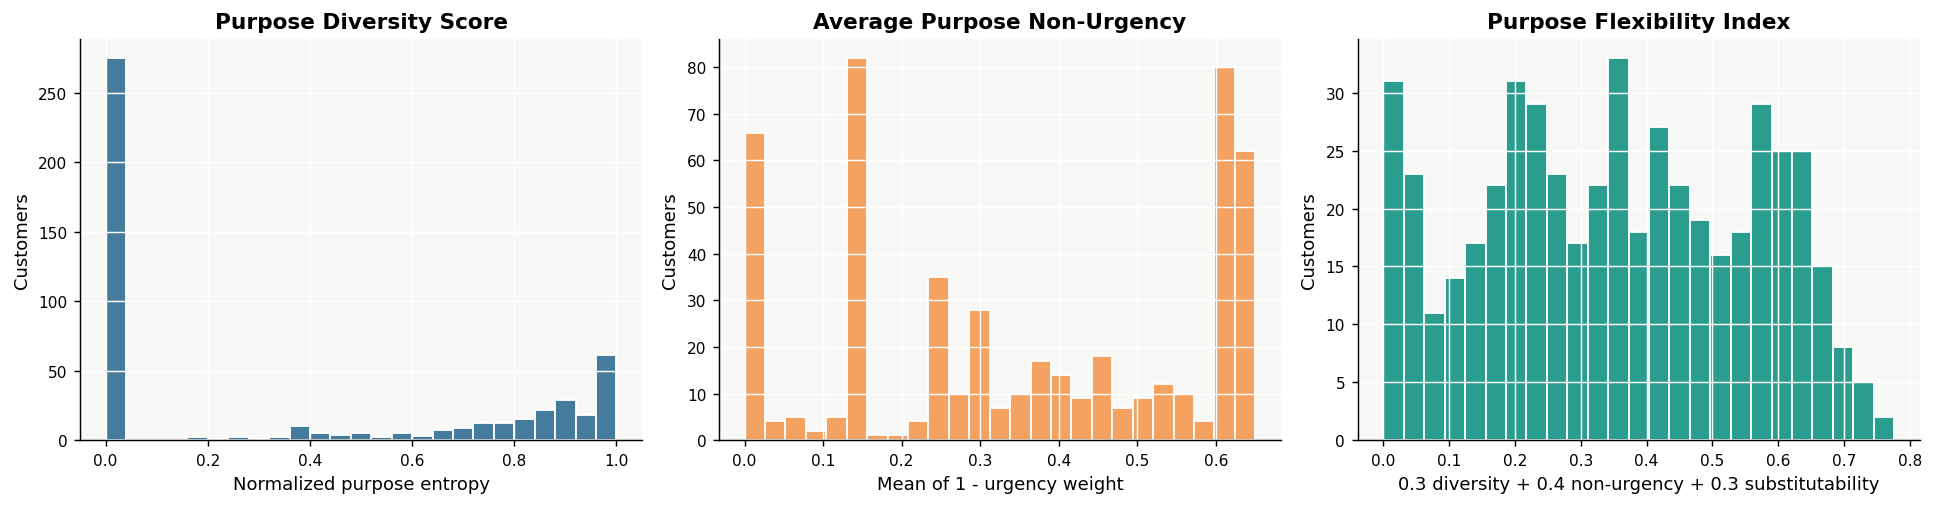

In [14]:
POI_PATH = Path('/scratch/umni5/a/li5125/DOE_analysis/RFI-Rider_flexibility_index-/birmingham_pois.csv')
poi_purpose = pd.read_csv(POI_PATH)
poi_purpose = poi_purpose.dropna(subset=['lat', 'lon']).copy()
poi_purpose['poi_name'] = poi_purpose['name'].fillna('').astype(str)
poi_purpose['poi_top_category'] = poi_purpose['top_category'].fillna('').astype(str)
poi_purpose['poi_sub_category'] = poi_purpose['sub_category'].fillna('').astype(str)

PURPOSE_URGENCY_WEIGHTS = {
    'Dialysis': 1.00,
    'Medical': 0.85,
    'Work': 0.75,
    'School': 0.70,
    'General': 0.40,
    'Other': 0.35,
}
PURPOSE_SUBSTITUTION_RADIUS_M = 800
NEAREST_PURPOSE_POI_RADIUS_M = 250
SELF_PURPOSE_POI_EXCLUSION_RADIUS_M = 25


def purpose_entropy_norm(s):
    counts = s.dropna().value_counts().to_numpy(dtype=float)
    if len(counts) <= 1:
        return 0.0
    probabilities = counts / counts.sum()
    entropy = -(probabilities * np.log(probabilities)).sum()
    return entropy / np.log(len(counts))


def infer_poi_purpose_class(row):
    text = ' '.join([
        str(row.get('poi_name', '')),
        str(row.get('poi_top_category', '')),
        str(row.get('poi_sub_category', '')),
    ]).lower()
    if 'dialysis' in text or 'renal' in text:
        return 'Dialysis'
    if any(k in text for k in [
        'hospital', 'medical', 'physician', 'doctor', 'clinic', 'health',
        'outpatient', 'dentist', 'mental health', 'pharmacies', 'drug stores', 'rehab'
    ]):
        return 'Medical'
    if any(k in text for k in ['school', 'college', 'universit', 'education', 'academy']):
        return 'School'
    if any(k in text for k in [
        'restaurant', 'eating', 'grocery', 'food', 'store', 'shopping', 'merchandise',
        'salon', 'personal care', 'amusement', 'recreation', 'religious', 'museum',
        'park', 'fitness', 'library', 'community'
    ]):
        return 'General'
    if any(k in text for k in [
        'office', 'bank', 'credit', 'insurance', 'automotive', 'repair', 'gasoline',
        'dealer', 'accounting', 'legal', 'employment', 'administrative', 'professional',
        'government', 'public order', 'postal'
    ]):
        return 'Work'
    return 'Other'


def scheduled_purpose_class(purpose):
    if purpose in {'Dialysis', 'Medical', 'Work', 'School'}:
        return purpose
    if purpose == 'General':
        return 'General'
    return 'Other'


poi_purpose['poi_purpose_class'] = poi_purpose.apply(infer_poi_purpose_class, axis=1)

purpose_trips = df_clean.copy()
purpose_trips['purpose_urgency_weight'] = (
    purpose_trips['Purpose'].map(PURPOSE_URGENCY_WEIGHTS).fillna(0.50)
)
purpose_trips['trip_purpose_non_urgency_score'] = 1 - purpose_trips['purpose_urgency_weight']
purpose_trips['scheduled_purpose_class'] = purpose_trips['Purpose'].apply(scheduled_purpose_class)

unique_purpose_destinations = (
    purpose_trips[['dropoff_address', 'dropoff_lat', 'dropoff_lon', 'scheduled_purpose_class']]
    .drop_duplicates()
    .reset_index(drop=True)
)

purpose_poi_distances_m = haversine_matrix_m(
    unique_purpose_destinations['dropoff_lat'],
    unique_purpose_destinations['dropoff_lon'],
    poi_purpose['lat'],
    poi_purpose['lon'],
)
nearest_purpose_poi_idx = purpose_poi_distances_m.argmin(axis=1)
nearest_purpose_poi_distance_m = purpose_poi_distances_m[np.arange(len(unique_purpose_destinations)), nearest_purpose_poi_idx]
nearest_purpose_pois = poi_purpose.iloc[nearest_purpose_poi_idx].reset_index(drop=True)
nearest_purpose_poi_matched = nearest_purpose_poi_distance_m <= NEAREST_PURPOSE_POI_RADIUS_M

unique_purpose_destinations['nearest_poi_purpose_class'] = np.where(
    nearest_purpose_poi_matched,
    nearest_purpose_pois['poi_purpose_class'],
    np.nan,
)
unique_purpose_destinations['nearest_poi_name'] = nearest_purpose_pois['poi_name']
unique_purpose_destinations['nearest_poi_top_category'] = nearest_purpose_pois['poi_top_category']
unique_purpose_destinations['nearest_poi_distance_m'] = nearest_purpose_poi_distance_m
unique_purpose_destinations['substitution_purpose_class'] = np.where(
    unique_purpose_destinations['scheduled_purpose_class'].isin(['General', 'Other'])
    & unique_purpose_destinations['nearest_poi_purpose_class'].notna(),
    unique_purpose_destinations['nearest_poi_purpose_class'],
    unique_purpose_destinations['scheduled_purpose_class'],
)

poi_purpose_class_array = poi_purpose['poi_purpose_class'].to_numpy()
purpose_alternative_counts = np.zeros(len(unique_purpose_destinations), dtype=int)
for i, purpose_class in enumerate(unique_purpose_destinations['substitution_purpose_class']):
    same_purpose = poi_purpose_class_array == purpose_class
    nearby_same_purpose = purpose_poi_distances_m[i, same_purpose] <= PURPOSE_SUBSTITUTION_RADIUS_M
    not_self_location = purpose_poi_distances_m[i, same_purpose] > SELF_PURPOSE_POI_EXCLUSION_RADIUS_M
    purpose_alternative_counts[i] = int((nearby_same_purpose & not_self_location).sum())

unique_purpose_destinations['same_purpose_pois_within_radius'] = purpose_alternative_counts
max_purpose_alternatives = unique_purpose_destinations['same_purpose_pois_within_radius'].max()
if max_purpose_alternatives > 0:
    unique_purpose_destinations['purpose_substitutability_score'] = (
        np.log1p(unique_purpose_destinations['same_purpose_pois_within_radius'])
        / np.log1p(max_purpose_alternatives)
    )
else:
    unique_purpose_destinations['purpose_substitutability_score'] = 0.0

purpose_trips = purpose_trips.merge(
    unique_purpose_destinations[[
        'dropoff_address', 'dropoff_lat', 'dropoff_lon', 'scheduled_purpose_class',
        'substitution_purpose_class', 'nearest_poi_name', 'nearest_poi_top_category',
        'nearest_poi_distance_m', 'same_purpose_pois_within_radius',
        'purpose_substitutability_score',
    ]],
    on=['dropoff_address', 'dropoff_lat', 'dropoff_lon', 'scheduled_purpose_class'],
    how='left',
)

customer_purpose_flexibility = (
    purpose_trips
    .groupby('Customer Number')
    .agg(
        trip_frequency=('Trip ID', 'count'),
        num_unique_purposes=('Purpose', 'nunique'),
        purpose_diversity_score=('Purpose', purpose_entropy_norm),
        purpose_urgency_score=('purpose_urgency_weight', 'mean'),
        purpose_non_urgency_score=('trip_purpose_non_urgency_score', 'mean'),
        purpose_substitutability_score=('purpose_substitutability_score', 'mean'),
        avg_same_purpose_pois_within_800m=('same_purpose_pois_within_radius', 'mean'),
        dominant_purpose=('Purpose', lambda s: s.value_counts().index[0] if not s.value_counts().empty else np.nan),
    )
    .reset_index()
)

customer_purpose_flexibility['purpose_flexibility_index'] = (
    0.3 * customer_purpose_flexibility['purpose_diversity_score']
    + 0.4 * customer_purpose_flexibility['purpose_non_urgency_score']
    + 0.3 * customer_purpose_flexibility['purpose_substitutability_score']
)
customer_purpose_flexibility = customer_purpose_flexibility.sort_values(
    ['purpose_flexibility_index', 'trip_frequency'], ascending=[False, False]
)

print(f"Customers in purpose flexibility analysis: {len(customer_purpose_flexibility):,}")
print('Purpose urgency weights used:')
display(pd.DataFrame({
    'Purpose': list(PURPOSE_URGENCY_WEIGHTS.keys()),
    'urgency_weight': list(PURPOSE_URGENCY_WEIGHTS.values()),
    'non_urgency_score': [1 - v for v in PURPOSE_URGENCY_WEIGHTS.values()],
}).style.format({'urgency_weight': '{:.2f}', 'non_urgency_score': '{:.2f}'}))

print('Top riders by purpose flexibility index:')
display(customer_purpose_flexibility.head(20).style.format({
    'trip_frequency': '{:,.0f}',
    'num_unique_purposes': '{:,.0f}',
    'purpose_diversity_score': '{:.3f}',
    'purpose_urgency_score': '{:.3f}',
    'purpose_non_urgency_score': '{:.3f}',
    'purpose_substitutability_score': '{:.3f}',
    'avg_same_purpose_pois_within_800m': '{:,.1f}',
    'purpose_flexibility_index': '{:.3f}',
}))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(
    customer_purpose_flexibility['purpose_diversity_score'].dropna(),
    bins=25,
    color='#457b9d',
    edgecolor='white',
)
axes[0].set_title('Purpose Diversity Score')
axes[0].set_xlabel('Normalized purpose entropy')
axes[0].set_ylabel('Customers')

axes[1].hist(
    customer_purpose_flexibility['purpose_non_urgency_score'].dropna(),
    bins=25,
    color='#f4a261',
    edgecolor='white',
)
axes[1].set_title('Average Purpose Non-Urgency')
axes[1].set_xlabel('Mean of 1 - urgency weight')
axes[1].set_ylabel('Customers')

axes[2].hist(
    customer_purpose_flexibility['purpose_flexibility_index'].dropna(),
    bins=25,
    color='#2a9d8f',
    edgecolor='white',
)
axes[2].set_title('Purpose Flexibility Index')
axes[2].set_xlabel('0.3 diversity + 0.4 non-urgency + 0.3 substitutability')
axes[2].set_ylabel('Customers')

plt.tight_layout()
plt.show()



### Combined Rider Flexibility Index

This cell combines the three flexibility dimensions and subtracts rider regularity:

```text
RFI_raw = 0.4 * temporal_flexibility
        + 0.3 * geographical_flexibility
        + 0.3 * purpose_flexibility

RFI_adjusted_minus_regularity = RFI_raw - Rider_regularity_index
```

Temporal flexibility is min-max normalized before combination because it is measured in entropy/minute units, while geographical and purpose flexibility are already built on 0-1-like scales. The 3D figure visualizes riders in temporal-purpose-geographical flexibility space, colored by the adjusted RFI.



Customers in combined rider flexibility index: 502
Combined index formula: RFI_raw = 0.4*TF + 0.3*GF + 0.3*PF
Adjusted formula: RFI_adjusted_minus_regularity = RFI_raw - Rider_regularity_index


,Customer Number,temporal_trip_frequency,temporal_flexibility_index,average_E_i_min,earliest_pickup_time_entropy,actual_pickup_match_rate,geographical_flexibility_index,destination_diversity_score,destination_radius_score_norm,alternative_location_availability_score,purpose_flexibility_index,purpose_diversity_score,purpose_non_urgency_score,purpose_substitutability_score,Rider_regularity_index,trip_frequency,dominant_OD_share,dominant_pickup_hour_share,dominant_purpose_share,dominant_weekday_share,temporal_flexibility_score_norm,RFI_raw,RFI_adjusted_minus_regularity
364,5536,20,3.384,0.00,3.384,100.0%,0.449,0.868,0.414,0.162,0.712,1.000,0.625,0.539,0.230,20,10.00%,15.00%,50.00%,45.00%,0.951,0.729,0.499
129,3183,41,3.211,0.00,3.211,100.0%,0.448,0.778,0.292,0.316,0.656,0.933,0.490,0.601,0.212,41,14.63%,17.07%,41.46%,19.51%,0.902,0.692,0.480
324,5148,25,3.303,0.00,3.303,96.0%,0.442,0.801,0.308,0.273,0.646,0.887,0.556,0.524,0.236,25,8.00%,16.00%,56.00%,44.00%,0.928,0.697,0.461
339,5348,27,3.560,0.00,3.560,100.0%,0.418,0.816,0.495,0.061,0.514,0.886,0.524,0.127,0.222,27,11.11%,14.81%,48.15%,37.04%,1.000,0.679,0.457
416,6130,30,3.028,0.00,3.028,100.0%,0.475,0.840,0.280,0.348,0.664,0.860,0.537,0.639,0.257,30,6.67%,26.67%,60.00%,30.00%,0.851,0.682,0.425
98,2987,29,3.142,0.00,3.142,100.0%,0.382,0.794,0.297,0.137,0.642,0.999,0.626,0.307,0.255,29,17.24%,20.69%,51.72%,20.69%,0.883,0.660,0.405
281,4353,13,3.239,0.00,3.239,100.0%,0.462,0.890,0.445,0.152,0.583,0.890,0.615,0.234,0.277,13,15.38%,15.38%,69.23%,30.77%,0.910,0.677,0.401
300,4749,44,3.297,0.00,3.297,100.0%,0.448,0.734,0.293,0.349,0.607,0.825,0.552,0.463,0.291,44,29.55%,22.73%,40.91%,22.73%,0.926,0.687,0.396
463,9122,36,2.992,0.00,2.992,100.0%,0.392,0.796,0.121,0.293,0.658,0.836,0.587,0.573,0.264,36,13.89%,25.00%,50.00%,33.33%,0.840,0.651,0.387
60,2545,10,2.722,0.00,2.722,100.0%,0.488,0.845,0.339,0.331,0.771,0.971,0.630,0.759,0.300,10,20.00%,20.00%,60.00%,40.00%,0.765,0.683,0.383


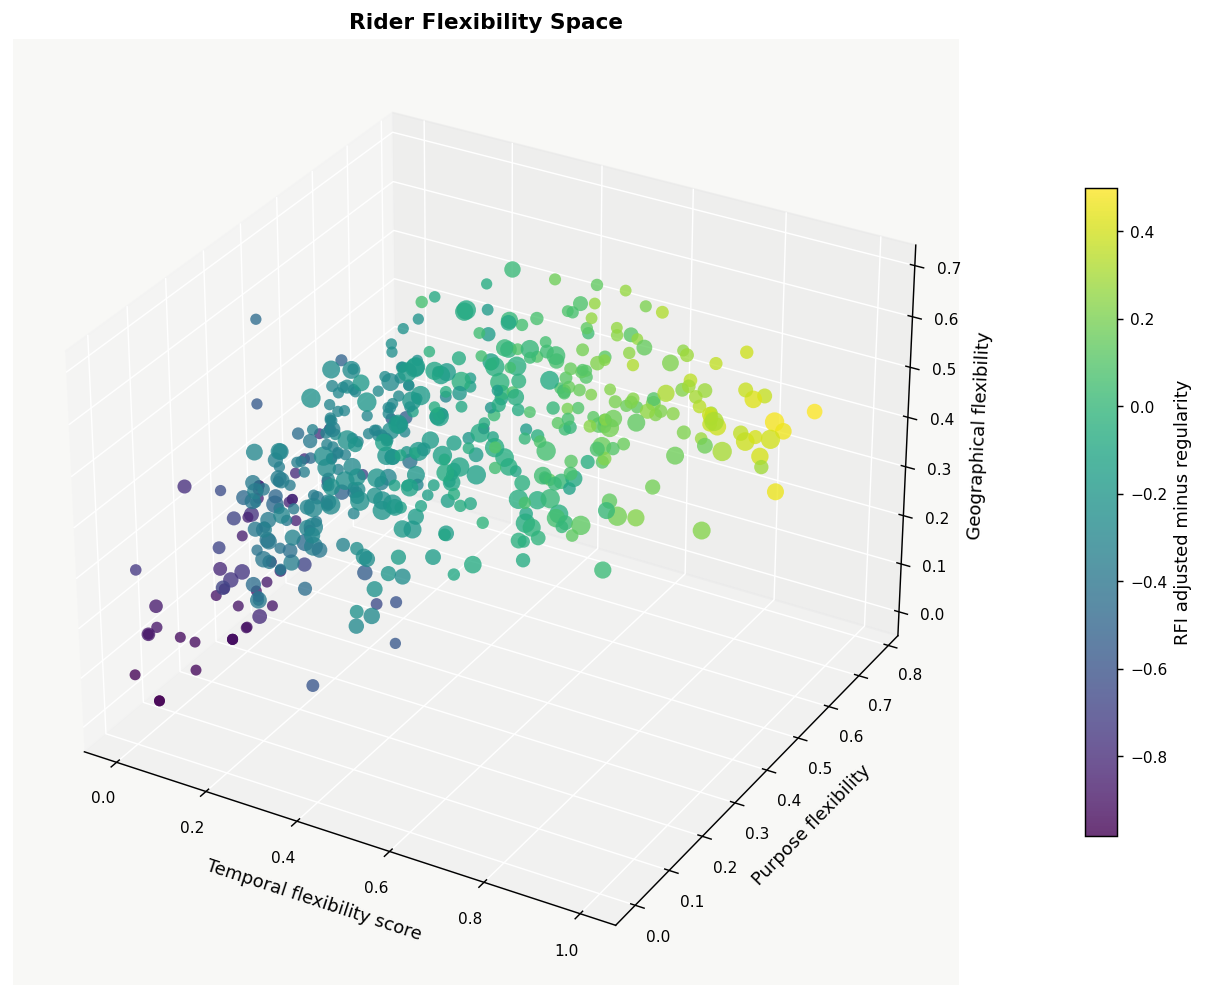

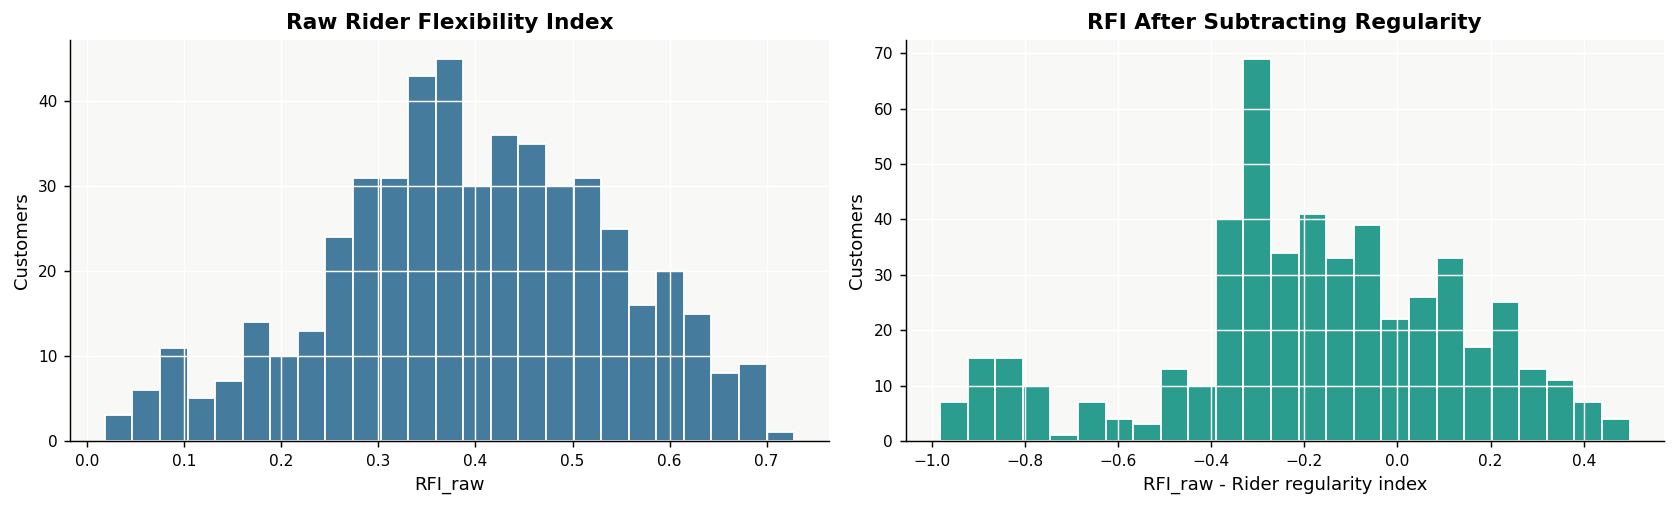

In [15]:
def minmax_normalize(s):
    s = s.astype(float)
    s_min = s.min(skipna=True)
    s_max = s.max(skipna=True)
    if pd.isna(s_min) or pd.isna(s_max) or s_max == s_min:
        return pd.Series(0.0, index=s.index)
    return (s - s_min) / (s_max - s_min)

rider_flexibility_index = (
    customer_temporal_flexibility[[
        'Customer Number', 'trip_frequency', 'temporal_flexibility_index',
        'average_E_i_min', 'earliest_pickup_time_entropy', 'actual_pickup_match_rate',
    ]]
    .rename(columns={'trip_frequency': 'temporal_trip_frequency'})
    .merge(
        customer_geographical_flexibility[[
            'Customer Number', 'geographical_flexibility_index',
            'destination_diversity_score', 'destination_radius_score_norm',
            'alternative_location_availability_score',
        ]],
        on='Customer Number',
        how='outer',
    )
    .merge(
        customer_purpose_flexibility[[
            'Customer Number', 'purpose_flexibility_index',
            'purpose_diversity_score', 'purpose_non_urgency_score',
            'purpose_substitutability_score',
        ]],
        on='Customer Number',
        how='outer',
    )
    .merge(
        rider_regularity[[
            'Customer Number', 'Rider_regularity_index', 'trip_frequency',
            'dominant_OD_share', 'dominant_pickup_hour_share',
            'dominant_purpose_share', 'dominant_weekday_share',
        ]],
        on='Customer Number',
        how='outer',
    )
)

# TF is normalized because temporal_flexibility_index is in entropy/minute units,
# while GF and PF were already constructed on 0-1-like scales.
rider_flexibility_index['temporal_flexibility_score_norm'] = minmax_normalize(
    rider_flexibility_index['temporal_flexibility_index']
)

rider_flexibility_index['RFI_raw'] = (
    0.4 * rider_flexibility_index['temporal_flexibility_score_norm']
    + 0.3 * rider_flexibility_index['geographical_flexibility_index']
    + 0.3 * rider_flexibility_index['purpose_flexibility_index']
)
rider_flexibility_index['RFI_adjusted_minus_regularity'] = (
    rider_flexibility_index['RFI_raw']
    - rider_flexibility_index['Rider_regularity_index']
)
rider_flexibility_index = rider_flexibility_index.sort_values(
    ['RFI_adjusted_minus_regularity', 'RFI_raw'], ascending=[False, False]
)

print(f"Customers in combined rider flexibility index: {len(rider_flexibility_index):,}")
print('Combined index formula: RFI_raw = 0.4*TF + 0.3*GF + 0.3*PF')
print('Adjusted formula: RFI_adjusted_minus_regularity = RFI_raw - Rider_regularity_index')

display(rider_flexibility_index.head(20).style.format({
    'temporal_trip_frequency': '{:,.0f}',
    'trip_frequency': '{:,.0f}',
    'temporal_flexibility_index': '{:.3f}',
    'temporal_flexibility_score_norm': '{:.3f}',
    'average_E_i_min': '{:.2f}',
    'earliest_pickup_time_entropy': '{:.3f}',
    'actual_pickup_match_rate': '{:.1%}',
    'geographical_flexibility_index': '{:.3f}',
    'purpose_flexibility_index': '{:.3f}',
    'Rider_regularity_index': '{:.3f}',
    'RFI_raw': '{:.3f}',
    'RFI_adjusted_minus_regularity': '{:.3f}',
    'destination_diversity_score': '{:.3f}',
    'destination_radius_score_norm': '{:.3f}',
    'alternative_location_availability_score': '{:.3f}',
    'purpose_diversity_score': '{:.3f}',
    'purpose_non_urgency_score': '{:.3f}',
    'purpose_substitutability_score': '{:.3f}',
    'dominant_OD_share': '{:.2%}',
    'dominant_pickup_hour_share': '{:.2%}',
    'dominant_purpose_share': '{:.2%}',
    'dominant_weekday_share': '{:.2%}',
}))

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
plot_data = rider_flexibility_index.dropna(subset=[
    'temporal_flexibility_score_norm',
    'purpose_flexibility_index',
    'geographical_flexibility_index',
    'RFI_adjusted_minus_regularity',
])
scatter = ax.scatter(
    plot_data['temporal_flexibility_score_norm'],
    plot_data['purpose_flexibility_index'],
    plot_data['geographical_flexibility_index'],
    c=plot_data['RFI_adjusted_minus_regularity'],
    cmap='viridis',
    s=35 + 2 * plot_data['trip_frequency'].fillna(1).clip(upper=40),
    alpha=0.78,
    edgecolors='none',
)
ax.set_title('Rider Flexibility Space')
ax.set_xlabel('Temporal flexibility score')
ax.set_ylabel('Purpose flexibility')
ax.set_zlabel('Geographical flexibility')
fig.colorbar(scatter, ax=ax, shrink=0.65, pad=0.1, label='RFI adjusted minus regularity')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(
    rider_flexibility_index['RFI_raw'].dropna(),
    bins=25,
    color='#457b9d',
    edgecolor='white',
)
axes[0].set_title('Raw Rider Flexibility Index')
axes[0].set_xlabel('RFI_raw')
axes[0].set_ylabel('Customers')

axes[1].hist(
    rider_flexibility_index['RFI_adjusted_minus_regularity'].dropna(),
    bins=25,
    color='#2a9d8f',
    edgecolor='white',
)
axes[1].set_title('RFI After Subtracting Regularity')
axes[1].set_xlabel('RFI_raw - Rider regularity index')
axes[1].set_ylabel('Customers')

plt.tight_layout()
plt.show()



# 3. Add the zone categorin.

In [11]:
CBG_PATH = Path("/scratch/umni5/a/li5125/DOE_analysis/RFI-Rider_flexibility_index-/jefferson_county_cbg_data_2021.csv")
df_cbg = pd.read_csv(CBG_PATH)

print(f"CBG rows: {len(df_cbg):,}")
print(f"CBG columns: {list(df_cbg.columns)}")
df_cbg.head(3)


CBG rows: 583
CBG columns: ['NAME', 'Total_Population', 'Median_Household_Income', 'Mean_Household_Income', 'Under_5', 'Age_5_to_9', 'Age_10_to_14', 'Age_15_to_19', 'Age_20_to_24', 'Age_25_to_34', 'Age_35_to_44', 'Age_45_to_54', 'Age_55_to_64', 'Age_65_to_74', 'Age_75_plus', 'Income_Less_10k', 'Income_10k_15k', 'Income_15k_20k', 'Income_20k_25k', 'Income_25k_35k', 'Income_35k_50k', 'Income_50k_75k', 'Income_75k_100k', 'Income_100k_150k', 'Income_150k_200k', 'Income_200k_plus', 'White_Alone', 'Black_Alone', 'American_Indian_Alone', 'Asian_Alone', 'Pacific_Islander_Alone', 'Other_Race_Alone', 'Two_Or_More_Races', 'No_Schooling', 'High_School_Grad', 'Associates_Degree', 'Bachelors_Degree', 'Graduate_or_Professional_Degree', 'Total_Male', 'Total_Female', 'state', 'county', 'tract', 'block group']


,NAME,Total_Population,Median_Household_Income,Mean_Household_Income,Under_5,Age_5_to_9,Age_10_to_14,Age_15_to_19,Age_20_to_24,Age_25_to_34,...,High_School_Grad,Associates_Degree,Bachelors_Degree,Graduate_or_Professional_Degree,Total_Male,Total_Female,state,county,tract,block group
0,"Block Group 1, Census Tract 1, Jefferson Count...",501.0,-666666666.0,12598900.0,24.0,8.0,12.0,73.0,0.0,0.0,...,39.0,47.0,39.0,16.0,294.0,207.0,1,73,100,1
1,"Block Group 2, Census Tract 1, Jefferson Count...",1011.0,39531.0,13552600.0,0.0,44.0,0.0,34.0,0.0,39.0,...,262.0,9.0,16.0,9.0,625.0,386.0,1,73,100,2
2,"Block Group 3, Census Tract 1, Jefferson Count...",278.0,36302.0,3025600.0,0.0,0.0,0.0,0.0,0.0,0.0,...,165.0,4.0,0.0,0.0,139.0,139.0,1,73,100,3


# 4. Add the Alabama block group shapefile, filters to Jefferson County CBG polygons 

Pickup points mapped to CBGs: 6,757 / 6,857
Dropoff points mapped to CBGs: 6,756 / 6,857
Pickup blocks: 268; dropoff blocks: 266; overlap: 260


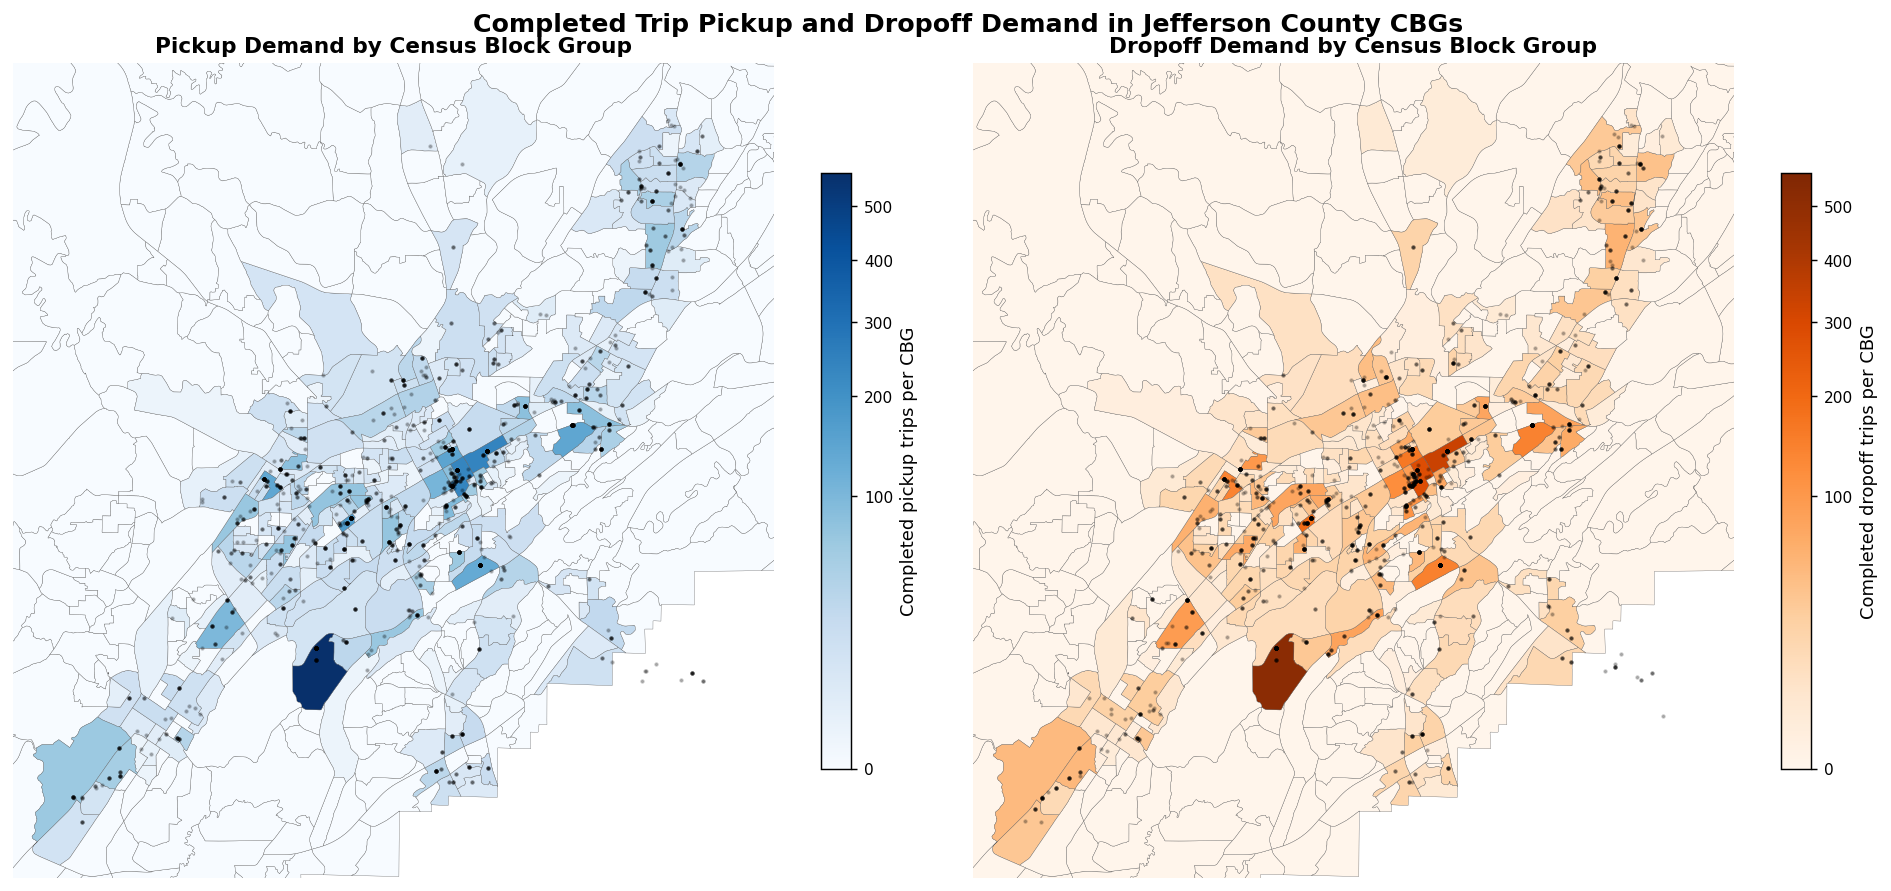

In [12]:
import geopandas as gpd

BG_PATH = Path("/scratch/umni5/a/li5125/DOE_analysis/RFI-Rider_flexibility_index-/tl_2021_01_bg/tl_2021_01_bg.shp")

# Load Jefferson County block group polygons and attach the CBG attributes.
cbg_poly = gpd.read_file(BG_PATH)
cbg_poly = cbg_poly[(cbg_poly['STATEFP'] == '01') & (cbg_poly['COUNTYFP'] == '073')].copy()

df_cbg = df_cbg.copy()
df_cbg['GEOID'] = (
    df_cbg['state'].astype(int).astype(str).str.zfill(2)
    + df_cbg['county'].astype(int).astype(str).str.zfill(3)
    + df_cbg['tract'].astype(int).astype(str).str.zfill(6)
    + df_cbg['block group'].astype(int).astype(str).str.zfill(1)
)
cbg_poly = cbg_poly.merge(df_cbg, on='GEOID', how='left')

# Spatially mark each trip's pickup and dropoff block group.
pickup_points = gpd.GeoDataFrame(
    df_clean[['pickup_lon', 'pickup_lat']].copy(),
    geometry=gpd.points_from_xy(df_clean['pickup_lon'], df_clean['pickup_lat']),
    crs='EPSG:4326',
).to_crs(cbg_poly.crs)
pickup_points['trip_index'] = df_clean.index

dropoff_points = gpd.GeoDataFrame(
    df_clean[['dropoff_lon', 'dropoff_lat']].copy(),
    geometry=gpd.points_from_xy(df_clean['dropoff_lon'], df_clean['dropoff_lat']),
    crs='EPSG:4326',
).to_crs(cbg_poly.crs)
dropoff_points['trip_index'] = df_clean.index

pickup_join = gpd.sjoin(pickup_points, cbg_poly[['GEOID', 'geometry']], how='left', predicate='within')
dropoff_join = gpd.sjoin(dropoff_points, cbg_poly[['GEOID', 'geometry']], how='left', predicate='within')

pickup_lookup = pickup_join.dropna(subset=['GEOID']).drop_duplicates('trip_index').set_index('trip_index')['GEOID']
dropoff_lookup = dropoff_join.dropna(subset=['GEOID']).drop_duplicates('trip_index').set_index('trip_index')['GEOID']
df_clean['pickup_bg_geoid'] = df_clean.index.map(pickup_lookup)
df_clean['dropoff_bg_geoid'] = df_clean.index.map(dropoff_lookup)

pickup_blocks = set(df_clean['pickup_bg_geoid'].dropna())
dropoff_blocks = set(df_clean['dropoff_bg_geoid'].dropna())

pickup_counts = df_clean['pickup_bg_geoid'].value_counts()
dropoff_counts = df_clean['dropoff_bg_geoid'].value_counts()
cbg_poly['pickup_trip_count'] = cbg_poly['GEOID'].map(pickup_counts).fillna(0).astype(int)
cbg_poly['dropoff_trip_count'] = cbg_poly['GEOID'].map(dropoff_counts).fillna(0).astype(int)

print(f"Pickup points mapped to CBGs: {df_clean['pickup_bg_geoid'].notna().sum():,} / {len(df_clean):,}")
print(f"Dropoff points mapped to CBGs: {df_clean['dropoff_bg_geoid'].notna().sum():,} / {len(df_clean):,}")
print(f"Pickup blocks: {len(pickup_blocks):,}; dropoff blocks: {len(dropoff_blocks):,}; overlap: {len(pickup_blocks & dropoff_blocks):,}")

from matplotlib.colors import PowerNorm

vmax = max(cbg_poly['pickup_trip_count'].max(), cbg_poly['dropoff_trip_count'].max())
norm = PowerNorm(gamma=0.45, vmin=0, vmax=vmax)
pickup_plot = pickup_points.sample(min(1500, len(pickup_points)), random_state=42)
dropoff_plot = dropoff_points.sample(min(1500, len(dropoff_points)), random_state=42)

minx, miny, maxx, maxy = pickup_points.total_bounds
dx = (maxx - minx) * 0.08
dy = (maxy - miny) * 0.08

fig, axes = plt.subplots(1, 2, figsize=(15, 7), sharex=True, sharey=True)

cbg_poly.plot(
    ax=axes[0], column='pickup_trip_count', cmap='Blues', norm=norm,
    edgecolor='#555555', linewidth=0.18, legend=True,
    legend_kwds={'label': 'Completed pickup trips per CBG', 'shrink': 0.72},
)
pickup_plot.plot(ax=axes[0], markersize=2.0, color='black', alpha=0.22)
axes[0].set_title('Pickup Demand by Census Block Group')

cbg_poly.plot(
    ax=axes[1], column='dropoff_trip_count', cmap='Oranges', norm=norm,
    edgecolor='#555555', linewidth=0.18, legend=True,
    legend_kwds={'label': 'Completed dropoff trips per CBG', 'shrink': 0.72},
)
dropoff_plot.plot(ax=axes[1], markersize=2.0, color='black', alpha=0.22)
axes[1].set_title('Dropoff Demand by Census Block Group')

for ax in axes:
    ax.set_xlim(minx - dx, maxx + dx)
    ax.set_ylim(miny - dy, maxy + dy)
    ax.set_axis_off()

fig.suptitle('Completed Trip Pickup and Dropoff Demand in Jefferson County CBGs', y=0.98, fontsize=14, fontweight='bold')
plt.tight_layout()


RFI = w1 * temporal_flexibility
    + w2 * purpose_flexibility
    + w3 * geographical_flexibility
    - w4 * regularity_penalty